# Vintage Stock Model — Architecture B: Equations & Design

This notebook derives the full mathematical framework for **Architecture B** — a GCAM-inspired vintage bin model with S-curve age-based retirement and profit-based economic shutdown.

**Purpose**: Discussion document. No model code is modified.

**Structure**:
1. Current approach & its limitations
2. S-curve survival — full derivation
3. Profit shutdown — economic early retirement
4. Multiplicative composition
5. VintageStock data structure
6. `retire_and_invest` algorithm
7. Historical initialization
8. Comparison — share blending vs vintage bins
9. B→C extensibility
10. Parameter table & summary

**Reference**: `notebooks/stock_turnover_design.md` for the full architecture comparison.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TIMESTEP = 5  # years
BASE_YEAR = 2020

print('Setup complete')

Setup complete


---
# Part 1: Current Approach & Its Limitations

## 1.1 Share Blending Equation

GHIM currently uses a first-order exponential blend from `ghim/energy/stock.py`:

$$
s_i^{\text{eff}}(t) = s_i^{\text{cur}}(t - \Delta t) + \min\!\left(\frac{\Delta t}{\tau},\, 1\right) \cdot \left[s_i^{\text{target}}(t) - s_i^{\text{cur}}(t - \Delta t)\right]
$$

where $\Delta t = 5$ years and $\tau$ is the sector turnover time (40 yr for electricity).

### Problems

| Problem | Consequence |
|---------|-------------|
| **No age tracking** | A 5-yr-old and 50-yr-old coal plant retire at the same rate |
| **Linear blend rate** | Real retirement follows S-curves, not constant fractions |
| **No capacity (EJ)** | Only tracks shares, not the physical stock producing them |
| **No early retirement** | Cannot model profit-based or policy-driven shutdown |
| **Asymptotic tail** | Coal never reaches exactly zero — even 100 yr after a ban, $\sim$3% persists |
| **New investment mixed** | Logit targets applied to total output, not just new investment |

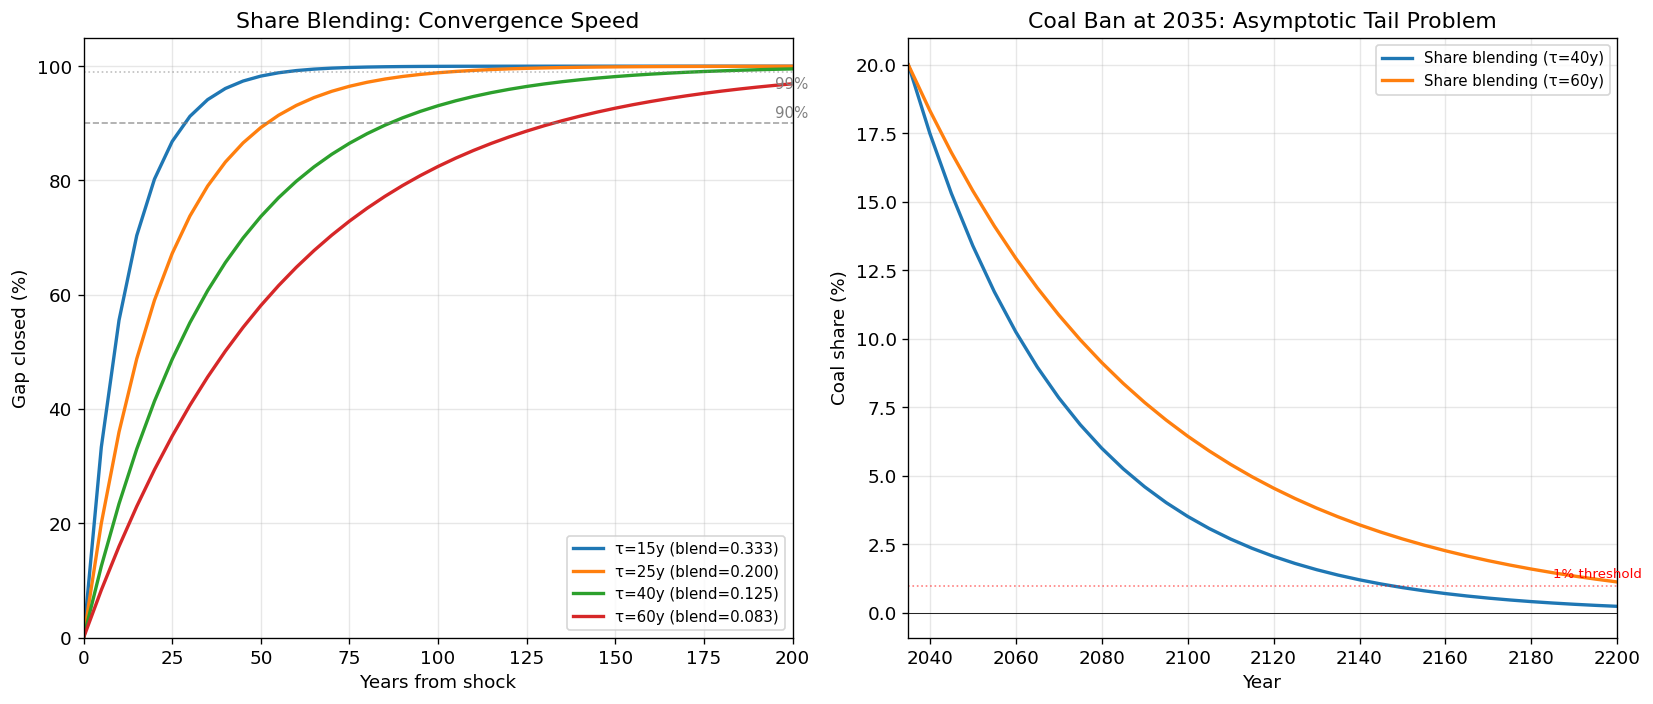

In [ ]:
# Demonstrate the asymptotic tail problem
tau_values = [15, 25, 40, 60]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: gap closure over time for different tau
ax = axes[0]
periods = np.arange(0, 41)
for tau in tau_values:
    blend = min(TIMESTEP / tau, 1.0)
    gap_closed = 1 - (1 - blend) ** periods
    ax.plot(periods * TIMESTEP, gap_closed * 100,
            label=f'\u03c4={tau}y (blend={blend:.3f})', lw=2)
ax.axhline(90, color='gray', ls='--', lw=1, alpha=0.7)
ax.axhline(99, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(195, 91, '90%', fontsize=9, color='gray')
ax.text(195, 96, '99%', fontsize=9, color='gray')
ax.set_xlabel('Years from shock')
ax.set_ylabel('Gap closed (%)')
ax.set_title('Share Blending: Convergence Speed')
ax.legend(fontsize=9)
ax.set_xlim(0, 200)
ax.set_ylim(0, 105)

# Right: coal ban scenario showing asymptotic tail
ax = axes[1]
for tau in [40, 60]:
    blend = min(TIMESTEP / tau, 1.0)
    coal = [0.20]  # 20% initial coal share
    for _ in range(40):
        coal.append(coal[-1] * (1 - blend))
    yrs = np.arange(len(coal)) * TIMESTEP + 2035
    ax.plot(yrs, np.array(coal) * 100, label=f'Share blending (\u03c4={tau}y)', lw=2)

ax.axhline(0, color='black', lw=0.5)
ax.axhline(1, color='red', ls=':', lw=1, alpha=0.5)
ax.text(2185, 1.3, '1% threshold', fontsize=8, color='red')
ax.set_xlabel('Year')
ax.set_ylabel('Coal share (%)')
ax.set_title('Coal Ban at 2035: Asymptotic Tail Problem')
ax.legend(fontsize=9)
ax.set_xlim(2035, 2200)

plt.tight_layout()
plt.show()

---
# Part 2: S-Curve Survival — Full Derivation

Source: GCAM `s_curve_shutdown_decider.cpp` line 125–130

## 2.1 Raw Logistic Function

The starting point is a standard logistic (sigmoid) centered at the half-life $t_{1/2}$:

$$
\sigma(a) = \frac{1}{1 + e^{k(a - t_{1/2})}}
$$

where $a$ = plant age (years), $k$ = steepness parameter (default 0.1), and $t_{1/2}$ = half-life (years).

**Properties**:
- $\sigma(t_{1/2}) = 0.5$ (50% survival at half-life)
- As $a \to \infty$: $\sigma \to 0$ (retirement)
- As $a \to 0$: $\sigma \to 1/(1 + e^{-k \cdot t_{1/2}})$ — **not exactly 1.0**

### The problem at age=0

For coal with $k=0.1$, $t_{1/2}=45$:

$$
\sigma(0) = \frac{1}{1 + e^{-0.1 \times 45}} = \frac{1}{1 + e^{-4.5}} \approx 0.989
$$

A brand-new plant would be 1.1% "retired" on day one. This is physically meaningless.

## 2.2 Displacement Correction

GCAM fixes this with an additive correction term:

**Initial displacement** (the gap at age=0):
$$
d_0 = 1 - \frac{1}{1 + e^{-k \cdot t_{1/2}}} = 1 - \sigma(0)
$$

**Linear ramp-down** (correction vanishes by half-life):
$$
d(a) = \begin{cases}
\left(1 - \frac{a}{t_{1/2}}\right) \cdot d_0 & a \le t_{1/2} \\
0 & a > t_{1/2}
\end{cases}
$$

This ensures:
- At $a=0$: $d(0) = d_0$, so $\sigma(0) + d(0) = 1.0$ exactly
- At $a = t_{1/2}$: $d(t_{1/2}) = 0$, so $\sigma(t_{1/2}) + d(t_{1/2}) = 0.5$ exactly
- For $a > t_{1/2}$: correction is zero, pure logistic applies

## 2.2b Why $\rho = 0.75$ (GHIM) vs $\rho = 0.5$ (GCAM)?

GCAM specifies `half.life` directly in `A23.globaltech_retirement.csv`. For coal, GCAM uses `half.life = 30` with `lifetime = 60`, giving $\rho = 30/60 = 0.5$. This means 50% of capacity has retired by the midpoint of its lifetime.

GHIM chose $\rho = 0.75$ — a **more conservative** retirement assumption where plants survive longer before peak decline. At $\rho = 0.75$, the S-curve stays near 1.0 for most of the plant's life, then drops steeply in the final quarter.

| Parameter | GCAM | GHIM ($\rho=0.75$) |
|-----------|------|---------------------|
| Coal: $L=60$, $t_{1/2}$ | 30 yr | 45 yr |
| Gas CC: $L=45$, $t_{1/2}$ | 22.5 yr | 33.75 yr |
| 50% survival age | Mid-life | 75% of life |
| Early retirement | More aggressive | More conservative |

**Rationale**: Real power plants often operate well past their "design lifetime" with maintenance. The $\rho=0.75$ curve better matches observed behavior where most retirements cluster in the final decades. This is configurable via `half_life_ratio` in `config.py`.

## 2.3 Combined Survival Formula

$$
S(a) = \begin{cases}
\sigma(a) + d(a) & 0 \le a < L \\
0 & a \ge L
\end{cases}
$$

where $L$ = retirement lifetime (hard cutoff) and $t_{1/2} = \rho \cdot L$ with $\rho = 0.75$ (half-life ratio).

Expanding fully:

$$
S(a) = \underbrace{\frac{1}{1 + e^{k(a - t_{1/2})}}}_\text{logistic} + \underbrace{\begin{cases} (1 - a/t_{1/2}) \cdot d_0 & a \le t_{1/2} \\ 0 & a > t_{1/2} \end{cases}}_\text{displacement correction}, \quad a < L
$$

### Hard cutoff technologies

Renewables (wind, solar) and electrolysis have near-zero variable costs, so S-curve decline is inappropriate. They use a **step function** instead:

$$
S_{\text{hard}}(a) = \begin{cases}
1 & a < L \\
0 & a \ge L
\end{cases}
$$

## 2.2c Renewable Hard Cutoff — GCAM Confirmation

**Yes** — this is exactly how GCAM implements it. Wind and solar have **no shutdown deciders** at all. The hard cutoff is enforced by the production state machine, not by a "shutdown decider that returns 1.0":

1. **`A23.globaltech_retirement.csv`**: Wind and solar rows have **blank** `half.life` and `median.shutdown.point` columns. No S-curve or profit shutdown decider is created for these technologies.

2. **`production_state_factory.cpp` (line ~108)**: When `age >= lifetime`, the `ProductionStateFactory` transitions the vintage into `RetiredProductionState`, which produces zero output — regardless of any decider.

3. **`vintage_production_state.cpp` (lines 131–134)**: The `calcShutdownCoefficient()` method iterates over the shutdown deciders vector. When the vector is **empty** (as for wind/solar), the loop body never executes and the method returns **1.0** (full survival). So during their lifetime, renewables always operate at 100%.

The logic is: renewables have near-zero variable costs (no fuel), so profit-based shutdown would never trigger anyway. And there is no physical "aging" degradation modeled — a solar panel either works or it doesn't. The hard cutoff at `lifetime` represents end-of-design-life replacement.

**GHIM mirrors this exactly**: `hard_cutoff_survival()` returns 1.0 for `age < L`, 0.0 for `age >= L`.

In [ ]:
def s_curve_survival(age, lifetime, half_life, steepness=0.1):
    """GCAM-style S-curve survival fraction.

    Matches s_curve_shutdown_decider.cpp lines 125-130 exactly.
    """
    if age >= lifetime:
        return 0.0
    if age <= 0:
        return 1.0
    if half_life <= 0:  # hard cutoff
        return 1.0

    # Raw logistic
    sigma = 1.0 / (1.0 + math.exp(steepness * (age - half_life)))

    # Displacement correction
    initial_dis = 1.0 - 1.0 / (1.0 + math.exp(steepness * (0.0 - half_life)))
    if age <= half_life:
        dis_adj = (1.0 - age / half_life) * initial_dis
    else:
        dis_adj = 0.0

    return max(0.0, min(1.0, sigma + dis_adj))


def hard_cutoff_survival(age, lifetime):
    """Step-function survival for renewables."""
    return 1.0 if age < lifetime else 0.0


# Quick sanity checks
print(f's_curve_survival(0,  60, 45) = {s_curve_survival(0, 60, 45):.4f}  (expect 1.0)')
print(f's_curve_survival(45, 60, 45) = {s_curve_survival(45, 60, 45):.4f}  (expect ~0.5)')
print(f's_curve_survival(60, 60, 45) = {s_curve_survival(60, 60, 45):.4f}  (expect 0.0)')

s_curve_survival(0,  60, 45) = 1.0000  (expect 1.0)
s_curve_survival(45, 60, 45) = 0.5000  (expect ~0.5)
s_curve_survival(60, 60, 45) = 0.0000  (expect 0.0)


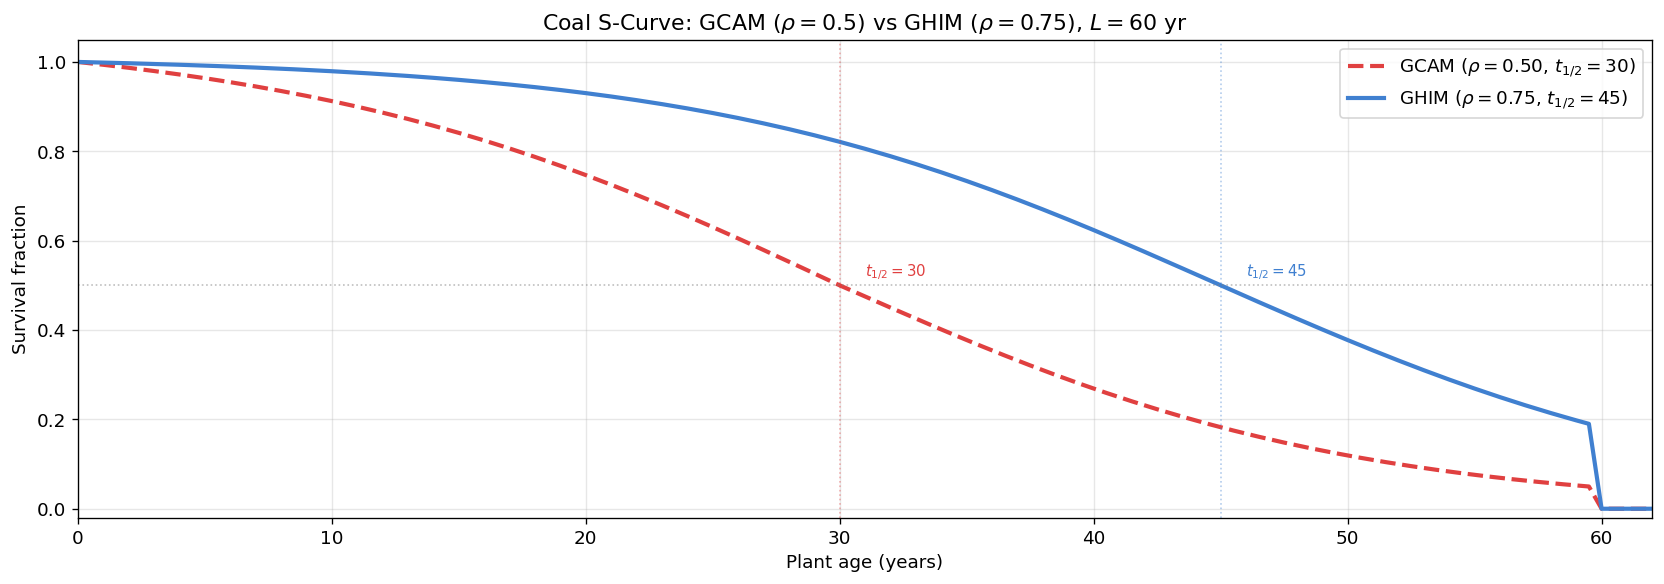

 Age  GCAM (rho=0.5)  GHIM (rho=0.75)  Difference
   0          1.0000           1.0000     +0.0000
  10          0.9124           0.9792     +0.0668
  20          0.7469           0.9302     +0.1834
  30          0.5000           0.8212     +0.3212
  40          0.2689           0.6237     +0.3547
  45          0.1824           0.5000     +0.3176
  50          0.1192           0.3775     +0.2583
  55          0.0759           0.2689     +0.1931
  60          0.0000           0.0000     +0.0000


In [ ]:
# Compare S-curve survival at rho=0.5 (GCAM) vs rho=0.75 (GHIM) for coal (L=60)
ages = np.arange(0, 65, 0.5)
L = 60

fig, ax = plt.subplots(figsize=(14, 5))

for rho, label, color, ls in [
    (0.50, r'GCAM ($\rho=0.50$, $t_{1/2}=30$)', '#E04040', '--'),
    (0.75, r'GHIM ($\rho=0.75$, $t_{1/2}=45$)', '#4080D0', '-'),
]:
    hl = rho * L
    surv = [s_curve_survival(a, L, hl) for a in ages]
    ax.plot(ages, surv, label=label, lw=2.5, color=color, ls=ls)

ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
ax.axvline(30, color='#E04040', ls=':', lw=1, alpha=0.4)
ax.axvline(45, color='#4080D0', ls=':', lw=1, alpha=0.4)
ax.text(31, 0.52, '$t_{1/2}=30$', fontsize=9, color='#E04040')
ax.text(46, 0.52, '$t_{1/2}=45$', fontsize=9, color='#4080D0')

ax.set_xlabel('Plant age (years)')
ax.set_ylabel('Survival fraction')
ax.set_title(r'Coal S-Curve: GCAM ($\rho=0.5$) vs GHIM ($\rho=0.75$), $L=60$ yr')
ax.legend(fontsize=11)
ax.set_xlim(0, 62)
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()

# Numerical comparison at key ages
print(f'{"Age":>4s}  {"GCAM (rho=0.5)":>14s}  {"GHIM (rho=0.75)":>15s}  {"Difference":>10s}')
for age in [0, 10, 20, 30, 40, 45, 50, 55, 60]:
    s_gcam = s_curve_survival(age, L, 0.50 * L)
    s_ghim = s_curve_survival(age, L, 0.75 * L)
    print(f'{age:4d}  {s_gcam:14.4f}  {s_ghim:15.4f}  {s_ghim - s_gcam:+10.4f}')

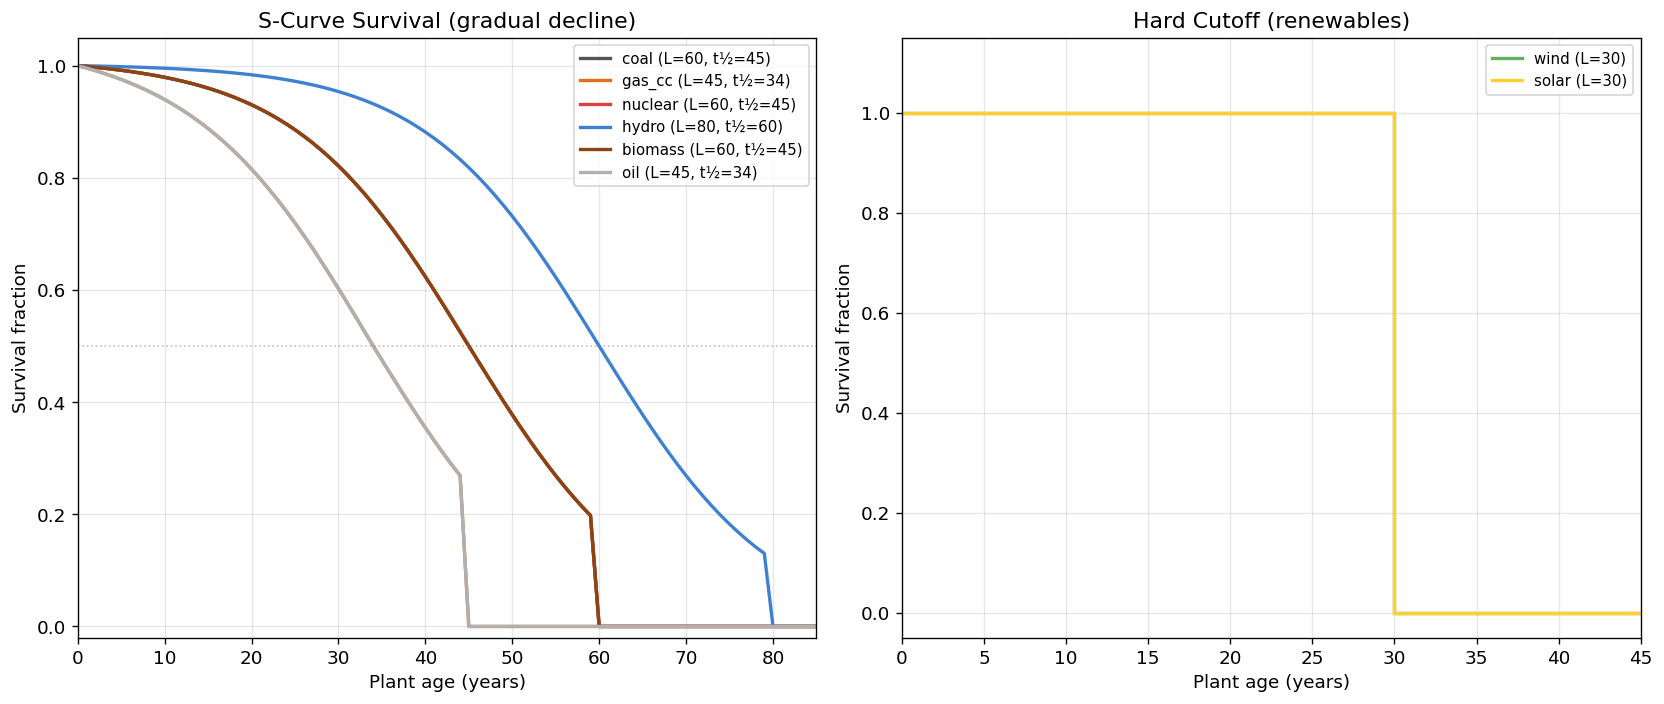

In [ ]:
# Plot S-curves for all 8 electricity technologies
tech_params = {
    # (retirement_lifetime, half_life, hard_cutoff?)
    'coal':    (60, 45, False),
    'gas_cc':  (45, 34, False),
    'nuclear': (60, 45, False),
    'hydro':   (80, 60, False),
    'wind':    (30, 0,  True),
    'solar':   (30, 0,  True),
    'biomass': (60, 45, False),
    'oil':     (45, 34, False),
}

colors = {
    'coal': '#555555', 'gas_cc': '#E07020', 'nuclear': '#E04040',
    'hydro': '#4080D0', 'wind': '#60B060', 'solar': '#FFD030',
    'biomass': '#8B4513', 'oil': '#B0B0B0',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: S-curve technologies
ax = axes[0]
ages = np.arange(0, 90, 1)
for tech, (lt, hl, hard) in tech_params.items():
    if hard:
        continue
    surv = [s_curve_survival(a, lt, hl) for a in ages]
    ax.plot(ages, surv, label=f'{tech} (L={lt}, t½={hl})',
            lw=2, color=colors[tech])
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Plant age (years)')
ax.set_ylabel('Survival fraction')
ax.set_title('S-Curve Survival (gradual decline)')
ax.legend(fontsize=9)
ax.set_xlim(0, 85)
ax.set_ylim(-0.02, 1.05)

# Right: hard cutoff technologies
ax = axes[1]
for tech, (lt, hl, hard) in tech_params.items():
    if not hard:
        continue
    surv = [hard_cutoff_survival(a, lt) for a in ages]
    ax.plot(ages, surv, label=f'{tech} (L={lt})',
            lw=2, color=colors[tech], drawstyle='steps-post')
ax.set_xlabel('Plant age (years)')
ax.set_ylabel('Survival fraction')
ax.set_title('Hard Cutoff (renewables)')
ax.legend(fontsize=9)
ax.set_xlim(0, 45)
ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# Numerical reference table: coal and gas_cc
ages_table = list(range(0, 65, 5))
data = {'Age (yr)': ages_table}

for tech, (lt, hl, hard) in [('coal', (60, 45, False)), ('gas_cc', (45, 34, False))]:
    if hard:
        data[f'{tech} survival'] = [hard_cutoff_survival(a, lt) for a in ages_table]
    else:
        data[f'{tech} survival'] = [round(s_curve_survival(a, lt, hl), 4) for a in ages_table]

df = pd.DataFrame(data)
print(df.to_string(index=False))

 Age (yr)  coal survival  gas_cc survival
        0         1.0000           1.0000
        5         0.9918           0.9754
       10         0.9792           0.9396
       15         0.9599           0.8879
       20         0.9302           0.8155
       25         0.8857           0.7195
       30         0.8212           0.6025
       35         0.7335           0.4750
       40         0.6237           0.3543
       45         0.5000           0.0000
       50         0.3775           0.0000
       55         0.2689           0.0000
       60         0.0000           0.0000


## 2.4 Connection to GCAM

The Python `s_curve_survival()` above is a direct port of GCAM's `s_curve_shutdown_decider.cpp` (lines 125–130):

```cpp
double initialDis = 1.0 - 1.0 / (1.0 + exp(mSteepness * (0.0 - mHalfLife)));
double disAdj = numYears <= mHalfLife
                ? (1.0 - numYears / mHalfLife) * initialDis
                : 0.0;
scaleFactor = 1.0 / (1.0 + exp(mSteepness * (numYears - mHalfLife))) + disAdj;
```

GCAM parameters come from `A23.globaltech_retirement.csv`:
- `steepness` maps to `mSteepness` (default 0.1)
- `half.life` maps to `mHalfLife`
- Hard cutoff enforced by the production state machine (vintage enters `RetiredProductionState` at `lifetime`)

For GHIM, we use $t_{1/2} = \rho \cdot L$ with $\rho = 0.75$ rather than specifying half-life separately. This means:

| GCAM | GHIM |
|------|------|
| `halfLife = 30` (coal) | `halfLife = 0.75 \times 60 = 45` |
| `halfLife = 22.5` (gas) | `halfLife = 0.75 \times 45 = 33.75` |

GHIM uses slightly longer half-lives (75% of lifetime vs GCAM's 50%), reflecting a more conservative retirement assumption. This can be tuned via `half_life_ratio`.

---
# Part 3: Profit Shutdown — Economic Early Retirement

Source: GCAM `profit_shutdown_decider.cpp` lines 117–119

## 3.1 Profit Rate

The profit rate $\pi$ measures how profitable a plant's variable operations are:

$$
\pi = \frac{\text{revenue} - c^{\text{var}}}{|c^{\text{var}}|}
$$

where revenue = electricity price $\times$ output, and variable cost includes:

$$
c_i^{\text{var}} = \frac{p_{\text{fuel}_i}}{\eta_i} + \text{O\&M}_i^{\text{var}} + \text{carbon\_price} \times \frac{e_i}{\eta_i}
$$

- $p_{\text{fuel}}$ = fuel price (\$/GJ)
- $\eta$ = efficiency
- $e_i$ = carbon coefficient (tC/GJ fuel input)
- O\&M$^{\text{var}}$ = variable O\&M (\$/GJ output)

**Capital costs are excluded** — they are sunk. The decision to keep operating depends only on whether revenue covers variable costs.

### Why only variable costs

A rational operator continues running a plant as long as `revenue > variable_cost`, regardless of whether the original investment has been recovered. Shutting down early destroys the option value of future profitable periods. This is the **sunk cost principle**.

### Renewables are immune

Wind and solar have near-zero variable costs (no fuel, minimal O\&M). Their profit rate is almost always positive, so the profit shutdown decider never activates. GCAM does not assign a profit shutdown decider to wind/solar.

## 3.1b Understanding $\eta$ and Why Carbon Coefficient Is Divided by It

**$\eta$ is thermal efficiency** — the ratio of useful energy output to fuel energy input:

$$\eta = \frac{\text{GJ}_{\text{output}}}{\text{GJ}_{\text{fuel input}}}$$

For a coal plant with $\eta = 0.39$: to produce 1 GJ of electricity, you must burn $1/0.39 = 2.56$ GJ of coal.

**Why divide carbon coefficient by $\eta$?** The carbon coefficient $e_i$ is defined per GJ of **fuel input** (tC/GJ-fuel). But costs are expressed per GJ of **output** (electricity). To get carbon cost per GJ output:

$$c^{\text{carbon}} = \text{carbon\_price} \times \underbrace{\frac{e_i}{\eta_i}}_{\text{tC per GJ output}}$$

The same logic applies to fuel cost: $c^{\text{fuel}} = p_{\text{fuel}} / \eta$ — you pay for fuel input, but price per unit of output.

### Worked Example

| | Coal | Gas CC | Oil |
|--|------|--------|-----|
| $e_i$ (tC/GJ fuel) | 0.0257 | 0.0153 | 0.0200 |
| $\eta_i$ | 0.39 | 0.55 | 0.37 |
| $e_i / \eta_i$ (tC/GJ output) | 0.0659 | 0.0278 | 0.0541 |
| **At $50/tC**: carbon cost ($/GJ out) | **3.30** | **1.39** | **2.70** |
| **At $100/tC**: carbon cost ($/GJ out) | **6.59** | **2.78** | **5.41** |

Coal's carbon intensity per unit output is 2.4× that of gas — both because coal has higher carbon content *and* lower efficiency.

## 3.2 Shutdown Formula

$$
P(\pi) = 1 - s_{\text{max}} \cdot \frac{(\pi_{50} + 1)^n}{(\pi_{50} + 1)^n + (\pi + 1)^n}
$$

where:
- $\pi_{50} = -0.1$ — profit rate at which 50% of capacity shuts down (median)
- $n = 6$ — steepness of the shutdown response
- $s_{\text{max}} = 1.0$ — maximum shutdown fraction (100% if deeply unprofitable)

**Interpretation**: $P(\pi) = $ fraction of capacity that **continues operating** (survival, not shutdown).

At $\pi = \pi_{50}$: $P = 1 - s_{\text{max}} \cdot 0.5 = 0.5$. Half the capacity shuts down when losing 10% on variable costs.

In [ ]:
def profit_shutdown(profit_rate, median=-0.1, steepness=6.0, max_shutdown=1.0):
    """GCAM-style profit shutdown survival fraction.

    Matches profit_shutdown_decider.cpp lines 117-119 exactly.

    Returns fraction of capacity that continues operating (1 - shutdown_fraction).
    """
    mid_to_steep = (median + 1.0) ** steepness
    profit_to_steep = (profit_rate + 1.0) ** steepness
    shutdown_frac = max_shutdown * mid_to_steep / (mid_to_steep + profit_to_steep)
    return max(0.0, min(1.0, 1.0 - shutdown_frac))


# Verify key values
print('Profit shutdown survival at key profit rates:')
for pi in [0.5, 0.1, 0.0, -0.1, -0.3, -0.5, -0.8]:
    p = profit_shutdown(pi)
    print(f'  pi={pi:+5.1f}  ->  survival={p:.3f}  (shutdown={1-p:.3f})')

Profit shutdown survival at key profit rates:
  pi= +0.5  ->  survival=0.955  (shutdown=0.045)
  pi= +0.1  ->  survival=0.769  (shutdown=0.231)
  pi= +0.0  ->  survival=0.653  (shutdown=0.347)
  pi= -0.1  ->  survival=0.500  (shutdown=0.500)
  pi= -0.3  ->  survival=0.181  (shutdown=0.819)
  pi= -0.5  ->  survival=0.029  (shutdown=0.971)
  pi= -0.8  ->  survival=0.000  (shutdown=1.000)


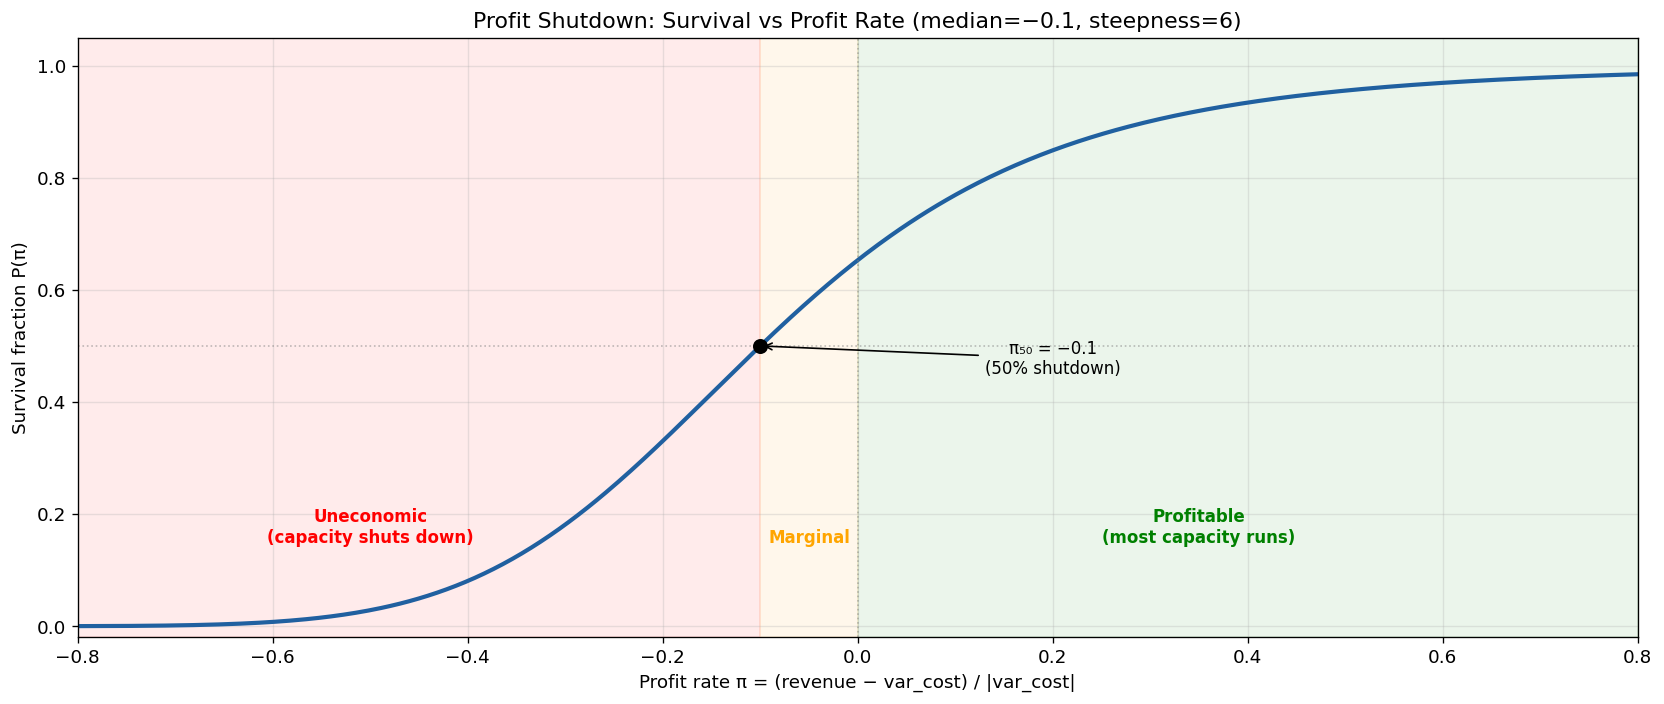

In [ ]:
# Plot profit shutdown curve
fig, ax = plt.subplots(figsize=(14, 6))

pi_range = np.linspace(-0.8, 0.8, 500)
surv = [profit_shutdown(p) for p in pi_range]

ax.plot(pi_range, surv, lw=2.5, color='#2060A0')

# Annotated regions
ax.axvspan(0.0, 0.8, alpha=0.08, color='green')
ax.axvspan(-0.1, 0.0, alpha=0.08, color='orange')
ax.axvspan(-0.8, -0.1, alpha=0.08, color='red')

ax.text(0.35, 0.15, 'Profitable\n(most capacity runs)', fontsize=10,
        ha='center', color='green', weight='bold')
ax.text(-0.05, 0.15, 'Marginal', fontsize=10,
        ha='center', color='orange', weight='bold')
ax.text(-0.5, 0.15, 'Uneconomic\n(capacity shuts down)', fontsize=10,
        ha='center', color='red', weight='bold')

# Mark the median point
ax.plot(-0.1, 0.5, 'ko', ms=8, zorder=5)
ax.annotate('\u03c0\u2085\u2080 = \u22120.1\n(50% shutdown)',
            xy=(-0.1, 0.5), xytext=(0.2, 0.45),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'),
            ha='center')

ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
ax.axvline(0, color='gray', ls=':', lw=1, alpha=0.5)

ax.set_xlabel('Profit rate \u03c0 = (revenue \u2212 var_cost) / |var_cost|')
ax.set_ylabel('Survival fraction P(\u03c0)')
ax.set_title('Profit Shutdown: Survival vs Profit Rate (median=\u22120.1, steepness=6)')
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()

---
# Part 3b: Multiplicative Composition

When both S-curve and profit shutdown apply to a vintage, they **multiply**:

$$
\text{output}_{i,v}(t) = C_{i,v} \cdot S_i(t - v) \cdot P_i\bigl(\pi_{i,v}(t)\bigr)
$$

- $S_i(t-v)$: physical aging (always active)
- $P_i(\pi)$: economic viability (active when carbon price makes fuel expensive)

**Example**: A 40-year-old coal plant ($S=0.42$) under carbon pricing that makes $\pi = -0.15$ ($P=0.38$):

$$
\text{effective output} = C_{\text{coal}, v} \times 0.42 \times 0.38 = 0.16 \cdot C
$$

Only 16% of original capacity operates. Neither mechanism alone would shut it down so aggressively.

### When to enable profit shutdown

- **Baseline runs**: Profit shutdown can be disabled (all $P=1$). S-curve alone provides realistic retirement.
- **Carbon price scenarios**: Enable profit shutdown — carbon pricing raises variable costs for fossil plants, pushing $\pi$ negative.
- **Fuel price shocks**: A natural gas price spike could make gas CC uneconomic.
- **Toggle**: `use_profit_shutdown=True/False` in the `VintageStock` constructor.

Coal breakeven carbon price: $188/tC
  (var cost without carbon: $5.63/GJ output)
  (electricity price: $18.0/GJ)


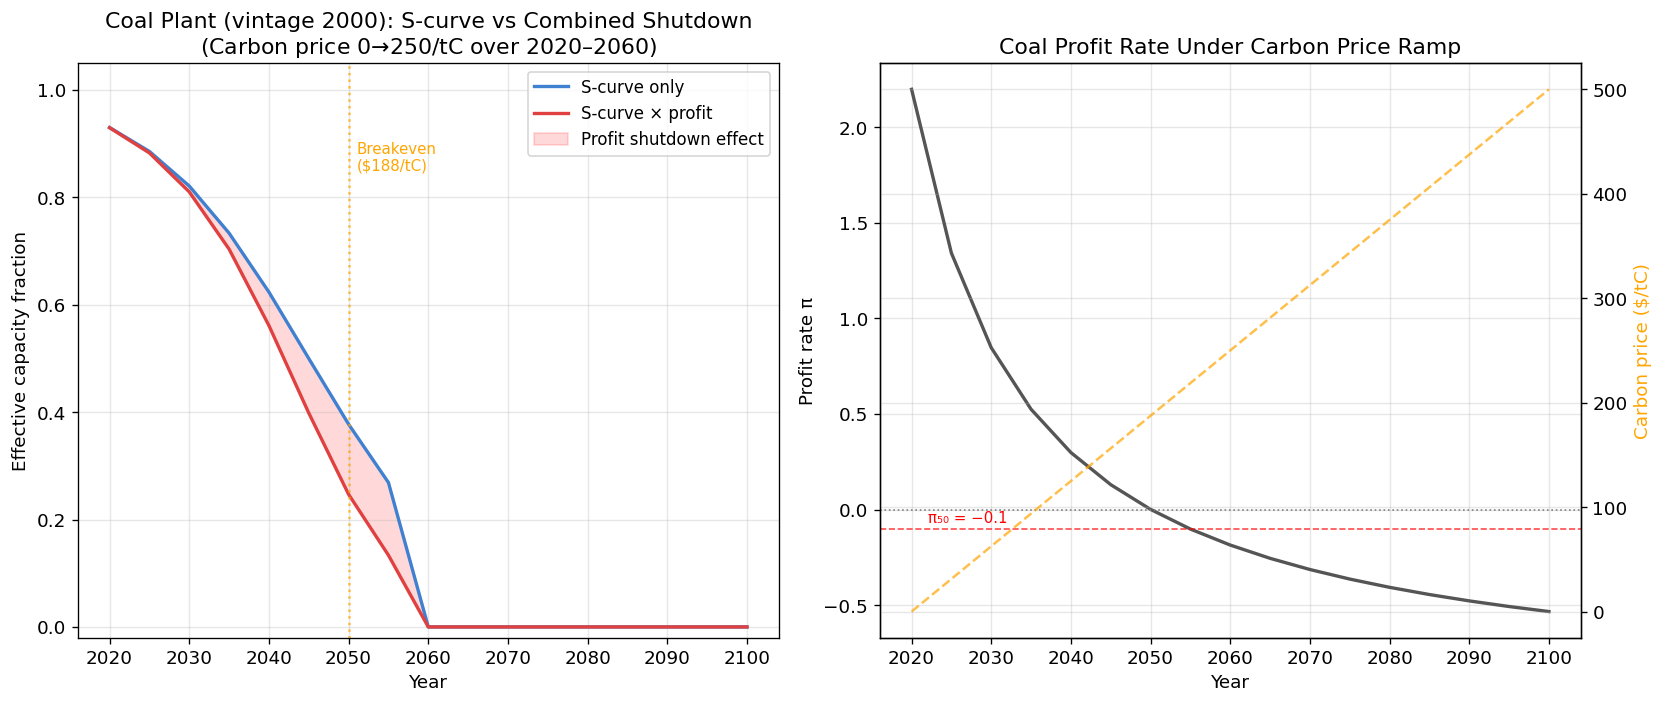

In [ ]:
# Combined example: coal plant with carbon price ramp
years = np.arange(2020, 2105, TIMESTEP)

# Coal plant installed in 2000
vintage_year = 2000
coal_lt, coal_hl = 60, 45

# Carbon price ramp: $0 in 2020, $250/tC in 2060
carbon_prices = {yr: max(0, 250.0 * (yr - 2020) / 40) for yr in years}

# Coal variable cost components
coal_fuel_price = 2.0     # $/GJ
coal_efficiency = 0.39
coal_om_var = 0.5         # $/GJ output
coal_carbon_coef = 0.0257 # tC/GJ fuel
elec_price = 18.0         # $/GJ (approx electricity price)

# Compute breakeven carbon price (where profit rate = 0)
# At breakeven: elec_price = fuel/eff + om_var + cp * carbon_coef/eff
# cp_breakeven = (elec_price - fuel/eff - om_var) * eff / carbon_coef
var_cost_no_carbon = coal_fuel_price / coal_efficiency + coal_om_var
cp_breakeven = (elec_price - var_cost_no_carbon) * coal_efficiency / coal_carbon_coef
print(f'Coal breakeven carbon price: ${cp_breakeven:.0f}/tC')
print(f'  (var cost without carbon: ${var_cost_no_carbon:.2f}/GJ output)')
print(f'  (electricity price: ${elec_price:.1f}/GJ)')

s_only = []  # S-curve survival only
combined = []  # S-curve x profit
profit_rates = []

for yr in years:
    age = yr - vintage_year
    s = s_curve_survival(age, coal_lt, coal_hl)

    # Variable cost with carbon price
    cp = carbon_prices[yr]
    var_cost = coal_fuel_price / coal_efficiency + coal_om_var + cp * coal_carbon_coef / coal_efficiency
    pi = (elec_price - var_cost) / abs(var_cost) if var_cost > 0 else 10.0
    p = profit_shutdown(pi)

    s_only.append(s)
    combined.append(s * p)
    profit_rates.append(pi)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: survival curves
ax = axes[0]
ax.plot(years, s_only, label='S-curve only', lw=2, color='#4080D0')
ax.plot(years, combined, label='S-curve \u00d7 profit', lw=2, color='#E04040')
ax.fill_between(years, combined, s_only, alpha=0.15, color='red',
                label='Profit shutdown effect')
ax.axvline(2020 + 40 * cp_breakeven / 250, color='orange', ls=':', lw=1.5, alpha=0.7)
ax.text(2020 + 40 * cp_breakeven / 250 + 1, 0.85,
        f'Breakeven\n(${cp_breakeven:.0f}/tC)', fontsize=9, color='orange')
ax.set_xlabel('Year')
ax.set_ylabel('Effective capacity fraction')
ax.set_title('Coal Plant (vintage 2000): S-curve vs Combined Shutdown\n(Carbon price $0\u2192$250/tC over 2020\u20132060)')
ax.legend(fontsize=10)
ax.set_ylim(-0.02, 1.05)

# Right: profit rate trajectory
ax = axes[1]
ax.plot(years, profit_rates, lw=2, color='#555555')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.axhline(-0.1, color='red', ls='--', lw=1, alpha=0.7)
ax.text(2022, -0.07, '\u03c0\u2085\u2080 = \u22120.1', fontsize=9, color='red')
# Secondary axis for carbon price
ax2 = ax.twinx()
ax2.plot(years, [carbon_prices[yr] for yr in years], lw=1.5, ls='--', color='orange', alpha=0.7)
ax2.set_ylabel('Carbon price ($/tC)', color='orange')
ax.set_xlabel('Year')
ax.set_ylabel('Profit rate \u03c0')
ax.set_title('Coal Profit Rate Under Carbon Price Ramp')

plt.tight_layout()
plt.show()

### Why a high carbon price is needed to trigger profit shutdown

The profit shutdown effect only becomes visible when the carbon price pushes the coal plant's **profit rate below zero** — meaning variable costs exceed revenue. With the parameters above:

- Coal variable cost (no carbon): $\frac{2.0}{0.39} + 0.5 = 5.63$ \$/GJ output
- Electricity price: $18.0$ \$/GJ
- **Breakeven carbon price**: $\frac{(18.0 - 5.63) \times 0.39}{0.0257} \approx 188$ \$/tC

At \$50/tC, coal's carbon cost adds only \$3.30/GJ output, giving a total variable cost of ~\$8.93/GJ — still well below the \$18/GJ electricity price. The profit rate stays at +1.0, and the profit shutdown survival is ~0.99 (invisible).

The ramp above uses **\$0→\$250/tC** over 2020–2060 so the breakeven is crossed mid-scenario and the red shaded area (profit shutdown acceleration) is clearly visible.

---
# Part 4: VintageStock Data Structure

## 4.1 Core Data

The fundamental state is a nested dictionary:

```python
capacity[tech_name][vintage_year] = EJ  # installed capacity
```

**Why EJ, not shares**: Capacity is a physical quantity. Shares are derived from capacity. Tracking EJ means:
- Learning curves accumulate correctly (cumulative GW installed)
- Retirement removes physical capacity, not abstract share points
- When demand grows, the gap between demand and surviving capacity determines new investment

**Memory**: ~30 vintages $\times$ 8 techs $\times$ 10 regions = 2,400 floats = $\sim$19 KB. Trivial.

## 4.2 Surviving Capacity with Profit Shutdown

Per-vintage effective capacity:

$$
Q_{i,v}^{\text{eff}}(t) = C_{i,v} \cdot S_i(t - v) \cdot P_i\bigl(\pi_{i,v}(t)\bigr)
$$

Surviving capacity per technology:

$$
Q_i^{\text{surv}}(t) = \sum_{v} Q_{i,v}^{\text{eff}}(t)
$$

## 4.3 Effective Shares

After computing surviving capacity and new investment $I_i(t)$:

$$
s_i(t) = \frac{Q_i^{\text{surv}}(t) + I_i(t)}{\sum_j \left[Q_j^{\text{surv}}(t) + I_j(t)\right]}
$$

These effective shares feed back into the rest of the model (emission accounting, electricity price, etc.).

---
# Part 5: `retire_and_invest` Algorithm

## 5.1 Step-by-Step Equations

Given: year $t$, total demand $D(t)$ in EJ, logit target shares $\hat{s}_i(t)$, optional profit rates $\pi_{i,v}(t)$.

**Step 1** — Per-vintage effective capacity:
$$
Q_{i,v}^{\text{eff}} = C_{i,v} \cdot S_i(t - v) \cdot P_i(\pi_{i,v})
$$

**Step 2** — Surviving capacity per technology:
$$
Q_i^{\text{surv}} = \sum_v Q_{i,v}^{\text{eff}}
$$

**Step 3** — Retirement gap:
$$
G = \max\bigl(D(t) - \sum_i Q_i^{\text{surv}},\; 0\bigr)
$$

**Step 4** — New investment allocated by logit:
$$
I_i = \hat{s}_i \cdot G
$$

**Step 5** — Record new vintage:
$$
C_{i,t} = I_i
$$

**Step 6** — Demand shrink case: if $D(t) < \sum_i Q_i^{\text{surv}}$, scale all surviving capacity proportionally:
$$
Q_i^{\text{surv}} \leftarrow Q_i^{\text{surv}} \cdot \frac{D(t)}{\sum_j Q_j^{\text{surv}}}
$$

No new investment in this case ($G = 0$).

## 5.1b How Investment and Operating Costs Affect Demand

Electricity **demand** depends on the **electricity price** seen by consumers. This price is a **weighted-average LCOE** across all generating technologies:

$$p_{\text{elec}} = \sum_i s_i \cdot \text{LCOE}_i$$

where LCOE includes capital, fuel, O&M, and carbon costs for **new builds**. Old vintages' sunk capital costs do **not** enter the electricity price — only their variable costs matter for dispatch decisions, and the electricity price reflects the cost of the marginal (newest) capacity.

The demand side then responds through income and price elasticities:

$$D(t) = D_0 \cdot \left(\frac{Y(t)}{Y_0}\right)^{\alpha} \cdot \left(\frac{p_{\text{elec}}(t)}{p_0}\right)^{\beta}$$

So the chain is:
1. **Investment cost** (capital) → enters new-build LCOE → raises weighted-average electricity price
2. **Operating cost** (fuel/O&M/carbon) → enters both new-build LCOE and dispatch decisions → raises electricity price
3. **Higher electricity price** → reduces demand via price elasticity $\beta < 0$
4. **Lower demand** → smaller retirement gap → less new investment needed

In Architecture B, investment cost affects how *expensive* electricity is (and thus demand), while operating cost also determines which *vintages survive* (via profit shutdown).

## 5.1c How to Calculate Technology Cost with Multiple Vintages

When a technology has old vintages (sunk capital) and new investment (full LCOE), the electricity price seen by demand is a **capacity-weighted average**:

$$p_{\text{elec}} = \frac{\sum_i \left[ Q_i^{\text{old}} \cdot c_i^{\text{var}} + Q_i^{\text{new}} \cdot \text{LCOE}_i \right]}{\sum_i \left[ Q_i^{\text{old}} + Q_i^{\text{new}} \right]}$$

where:
- $Q_i^{\text{old}} = \sum_v C_{i,v} \cdot S_i(t-v)$ — surviving capacity from past vintages
- $Q_i^{\text{new}} = I_i(t)$ — new investment this period
- $c_i^{\text{var}}$ = variable cost only (fuel/η + O&M + carbon cost) — capital is **sunk**
- $\text{LCOE}_i$ = full levelized cost (capital + fuel/η + O&M + carbon cost)

**Concrete example** at year 2040 for coal:

| Vintage type | Capacity (EJ) | Cost ($/GJ) | Contribution |
|-------------|---------------|-------------|--------------|
| Old vintages (2000–2035) | 15.2 | 5.63 (var only) | 85.6 |
| New vintage (2040) | 2.1 | 12.40 (full LCOE) | 26.0 |
| **Weighted average** | **17.3** | **$\frac{85.6 + 26.0}{17.3} = 6.45$** | |

Old capacity dominates the weighted average, keeping the electricity price low even when new builds are expensive. As old vintages retire and new (possibly more expensive) capacity replaces them, the price rises gradually.

This is why vintage tracking matters for demand: the electricity price trajectory depends on the **age structure** of the fleet, not just the current LCOE of new builds.

## 5.2 Profit Rate Per Vintage

For each technology $i$ and vintage $v$, the profit rate depends on the **current** fuel price and carbon price, not the vintage's original costs:

$$
\pi_{i,v} = \frac{p_{\text{elec}} - c_i^{\text{var}}}{|c_i^{\text{var}}|}
$$

where:

$$
c_i^{\text{var}} = \frac{p_{\text{fuel}_i}}{\eta_i} + \text{O\&M}_i^{\text{var}} + \text{carbon\_price} \times \frac{e_i}{\eta_i}
$$

Note: All vintages of the same technology have the **same** profit rate (efficiency and O\&M don't change with age in this simplified model). GCAM allows vintage-specific efficiencies, which we could add later.

In [ ]:
def retire_and_invest(
    capacity,           # dict[str, dict[int, float]] tech -> vintage_year -> EJ
    tech_names,         # list[str]
    year,               # current year
    target_shares,      # np.ndarray logit target shares
    total_demand_ej,    # total electricity demand
    lifetimes,          # dict[str, float]
    half_life_ratio=0.75,
    steepness=0.1,
    hard_cutoff_techs=None,
    profit_rates=None,  # optional: dict[str, float] tech -> profit rate
    profit_params=None, # optional: dict with median, steepness, max_shutdown
):
    """Standalone retire_and_invest for demonstration.

    Returns (effective_shares, new_investment_ej, surviving_per_tech).
    """
    if hard_cutoff_techs is None:
        hard_cutoff_techs = {'wind', 'solar', 'electrolysis'}
    if profit_params is None:
        profit_params = {'median': -0.1, 'steepness': 6.0, 'max_shutdown': 1.0}

    # Step 1-2: Compute surviving capacity per tech
    surviving = {}
    for tech in tech_names:
        lt = lifetimes[tech]
        hl = 0 if tech in hard_cutoff_techs else lt * half_life_ratio
        total = 0.0
        for v_yr, cap in capacity.get(tech, {}).items():
            age = year - v_yr
            if tech in hard_cutoff_techs:
                s = hard_cutoff_survival(age, lt)
            else:
                s = s_curve_survival(age, lt, hl, steepness)

            # Optional profit shutdown
            p = 1.0
            if profit_rates and tech in profit_rates:
                p = profit_shutdown(profit_rates[tech], **profit_params)

            total += cap * s * p
        surviving[tech] = total

    total_surviving = sum(surviving.values())

    # Step 3: Retirement gap
    new_investment_ej = max(total_demand_ej - total_surviving, 0.0)

    # Step 6: Demand shrink
    if total_demand_ej < total_surviving and total_surviving > 0:
        scale = total_demand_ej / total_surviving
        for tech in surviving:
            surviving[tech] *= scale
        total_surviving = total_demand_ej
        new_investment_ej = 0.0

    # Step 4-5: Allocate new investment
    target_shares = np.asarray(target_shares, dtype=float)
    for i, tech in enumerate(tech_names):
        new_cap = target_shares[i] * new_investment_ej
        if new_cap > 0:
            capacity.setdefault(tech, {})[year] = new_cap

    # Compute effective shares
    total = total_surviving + new_investment_ej
    if total <= 0:
        return target_shares.copy(), 0.0, surviving

    effective = np.zeros(len(tech_names))
    for i, tech in enumerate(tech_names):
        effective[i] = (surviving[tech] + capacity.get(tech, {}).get(year, 0.0)) / total

    return effective, new_investment_ej, surviving


print('retire_and_invest() defined')

retire_and_invest() defined


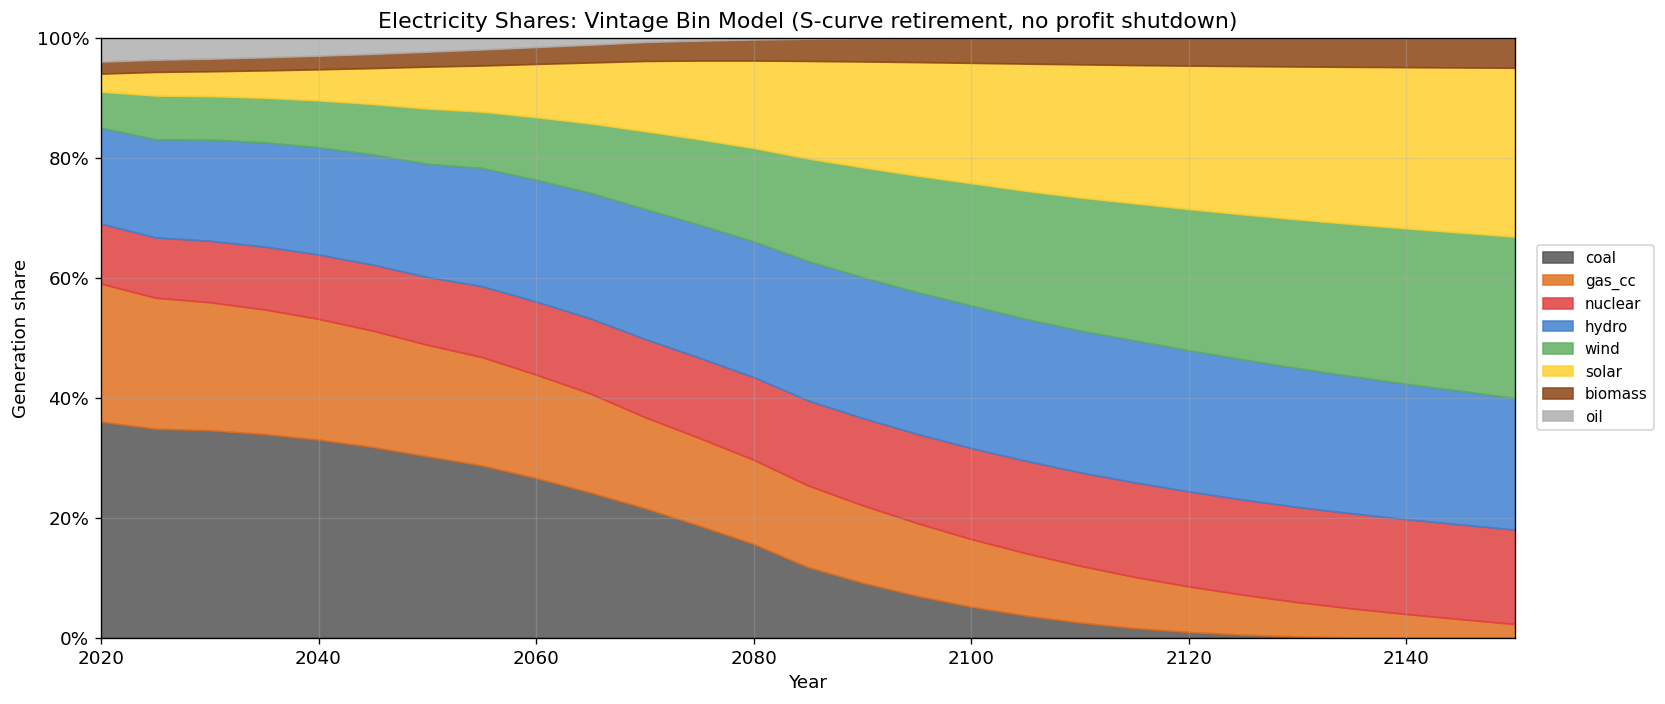

In [ ]:
# Simulation: 8-tech electricity sector 2020-2150
tech_names = ['coal', 'gas_cc', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'oil']
lifetimes = {'coal': 60, 'gas_cc': 45, 'nuclear': 60, 'hydro': 80,
             'wind': 30, 'solar': 30, 'biomass': 60, 'oil': 45}
hard_cutoff = {'wind', 'solar'}

# Base year shares and total
base_shares = np.array([0.36, 0.23, 0.10, 0.16, 0.06, 0.03, 0.02, 0.04])
base_total_ej = 100.0  # global ~100 EJ electricity

# Initialize capacity: uniform distribution across past vintages
capacity = {}
for i, tech in enumerate(tech_names):
    cap = base_shares[i] * base_total_ej
    lt = lifetimes[tech]
    n_vintages = max(1, int(lt // TIMESTEP))
    per_vintage = cap / n_vintages
    oldest = BASE_YEAR - int(lt) + TIMESTEP
    capacity[tech] = {}
    for yr in range(oldest, BASE_YEAR + 1, TIMESTEP):
        capacity[tech][yr] = per_vintage

# Evolving target shares (transition toward renewables)
def get_target_shares(year):
    """Stylized logit target shares shifting toward renewables."""
    t = max(0, (year - 2020) / 130)  # 0 to 1 over 2020-2150
    coal   = max(0, 0.36 * (1 - 2.0*t))
    gas    = max(0, 0.23 * (1 - 1.0*t))
    nuclear = 0.10 + 0.05 * t
    hydro  = 0.16
    wind   = 0.06 + 0.30 * t
    solar  = 0.03 + 0.35 * t
    biomass = 0.02 + 0.03 * t
    oil    = max(0, 0.04 * (1 - 3.0*t))
    arr = np.array([coal, gas, nuclear, hydro, wind, solar, biomass, oil])
    return arr / arr.sum()

# Run simulation
sim_years = list(range(2025, 2155, TIMESTEP))
demand_growth = 1.015  # 1.5% annual
demand = base_total_ej

share_history = {t: [base_shares[i]] for i, t in enumerate(tech_names)}
invest_history = {t: [0.0] for t in tech_names}
all_years = [BASE_YEAR]

for yr in sim_years:
    demand *= demand_growth ** TIMESTEP
    targets = get_target_shares(yr)
    eff, new_inv, surv = retire_and_invest(
        capacity, tech_names, yr, targets, demand,
        lifetimes, hard_cutoff_techs=hard_cutoff,
    )
    all_years.append(yr)
    for i, t in enumerate(tech_names):
        share_history[t].append(eff[i])
        invest_history[t].append(targets[i] * new_inv)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(all_years))
for tech in tech_names:
    vals = np.array(share_history[tech])
    ax.fill_between(all_years, bottom, bottom + vals,
                    label=tech, color=colors[tech], alpha=0.85)
    bottom += vals

ax.set_xlabel('Year')
ax.set_ylabel('Generation share')
# ax.set_title('Electricity Shares: Vintage Bin Model (S-curve retirement, no profit shutdown)')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
ax.set_xlim(2020, 2150)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

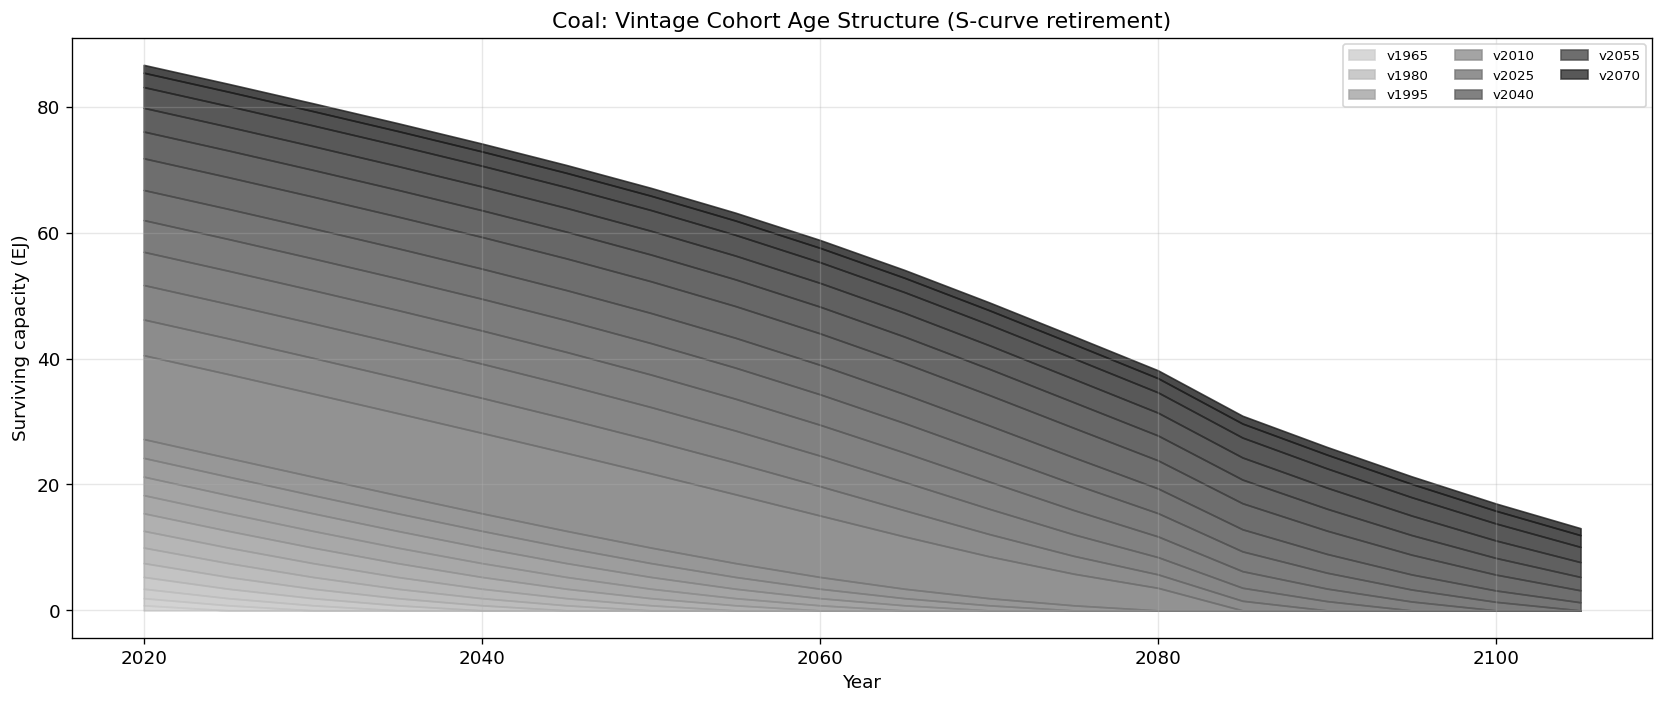

In [ ]:
# Stacked area plot of vintage cohorts for coal
coal_vintages = sorted(capacity['coal'].keys())

fig, ax = plt.subplots(figsize=(14, 6))

# For each year, compute surviving capacity of each coal vintage
plot_years = list(range(2020, 2110, TIMESTEP))
vintage_data = {}  # vintage_year -> list of surviving EJ

for v_yr in coal_vintages:
    vintage_data[v_yr] = []
    for yr in plot_years:
        age = yr - v_yr
        cap = capacity['coal'].get(v_yr, 0.0)
        s = s_curve_survival(age, 60, 45)
        vintage_data[v_yr].append(cap * s)

# Create a colormap from dark (old) to light (new)
n_vintages = len(coal_vintages)
cmap = plt.cm.Greys
bottom = np.zeros(len(plot_years))

for idx, v_yr in enumerate(coal_vintages):
    vals = np.array(vintage_data[v_yr])
    color = cmap(0.3 + 0.6 * idx / max(1, n_vintages - 1))
    label = f'v{v_yr}' if idx % 3 == 0 else None
    ax.fill_between(plot_years, bottom, bottom + vals,
                    color=color, alpha=0.8, label=label)
    bottom += vals

ax.set_xlabel('Year')
ax.set_ylabel('Surviving capacity (EJ)')
# ax.set_title('Coal: Vintage Cohort Age Structure (S-curve retirement)')
ax.legend(loc='upper right', fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

## 5.3 Key Behavioral Properties

1. **New investment only fills the gap**: Surviving capacity is computed first. Only the shortfall relative to demand receives new investment. This prevents building new coal plants when existing capacity suffices.

2. **Old capacity cannot grow**: Vintages can only decay. A vintage's capacity at installation is its maximum ever. S-curve and profit shutdown only reduce it.

3. **Hard lifetime guarantee**: Regardless of the S-curve shape, capacity reaches exactly zero at $a = L$. No asymptotic tail.

4. **Profit shutdown accelerates coal retirement under carbon pricing**: Without profit shutdown, a coal plant runs at reduced S-curve capacity until its physical lifetime. With profit shutdown, unprofitable plants reduce output earlier, creating a larger gap for clean investment.

5. **Demand shrink is safe**: If demand falls below surviving capacity, all vintages are proportionally scaled down. No negative capacity, no numerical issues.

---
# Part 6: Historical Initialization

## 6.1 Uniform Assumption

At the base year $t_0 = 2020$, distribute existing capacity across past vintages:

$$
C_{i,v} = \frac{s_i \cdot D_{\text{base}}}{N_i}, \quad v \in \{t_0 - L_i + \Delta t,\; t_0 - L_i + 2\Delta t,\; \ldots,\; t_0\}
$$

where $N_i = \lfloor L_i / \Delta t \rfloor$ is the number of vintage bins for technology $i$.

## 6.2 Limitations

Real investment was **not** uniform:

| Technology | Real investment pattern |
|------------|----------------------|
| Coal | Peaked in 1960s–1980s (OECD), 2000s–2010s (China/India) |
| Nuclear | Boom in 1970s–1980s, near-zero since |
| Solar | Near-zero before 2005, exponential after 2010 |
| Wind | Near-zero before 2000, rapid growth since 2010 |

Uniform initialization overestimates the number of very old solar/wind plants and underestimates the concentration of nuclear in the 1970s–1980s. However:
- The S-curve corrects old-plant overestimates within 2–3 periods
- Total capacity at base year is correct by construction
- A future improvement could use IEA/IRENA historical capacity age data

## 6.3 GCAM's Single Base-Year Vintage Approach — Recommended for GHIM

**Confirmed**: GCAM lumps ALL historical capacity into a **single base-year vintage** (the final calibration year). There are no per-historical-year vintages. This dramatically simplifies calibration:

- Only one vintage per technology at `BASE_YEAR` (e.g. 2020)
- Total capacity = observed generation in the calibration year
- No need to know historical investment patterns or plant ages
- The S-curve applies from age=0 at the base year, so old capacity retires naturally over the first few periods

**Recommendation**: Adopt this as the **GHIM default**. For each technology, initialize:

$$C_{i, t_0} = s_i^{\text{obs}} \cdot D_{\text{base}}$$

One vintage, one number per technology. The current uniform multi-vintage initialization (Section 6.1) becomes an optional enhancement for when we have real plant-level age data.

**Benefits**:
- Eliminates the arbitrary uniform distribution assumption
- Same calibration approach across electricity, transport, industry, buildings — reducing risk of miscalibration
- Matches the established GCAM methodology
- Easy to extend later with real vintage data (see next cell)

## 6.4 Power Plant Data for Future Calibration

The Global Energy Monitor tracker files at `data/powerplants/` contain excellent data for future vintage calibration:

| Tracker | File | Records | Vintage column |
|---------|------|---------|----------------|
| Coal | Global-Coal-Plant-Tracker-January-2026.xlsx | ~14.5K | `Start year`, `Plant age`, `Remaining lifetime` |
| Oil & Gas | Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2026.xlsx | ~14.8K | `Start year`, `Retired year` |
| Solar | Global-Solar-Power-Tracker-February-2026.xlsx | ~104K | `Start year` |
| Wind | Global-Wind-Power-Tracker-February-2026.xlsx | ~35K | `Start year` |
| Nuclear | Global-Nuclear-Power-Tracker-September-2025.xlsx | ~1.8K | `Start Year`, `Construction Start Date` |
| Hydropower | Global-Hydropower-Tracker-April-2025.xlsx | ~5.7K | `Start Year` |
| Bioenergy | Global-Bioenergy-Power-Tracker-GBPT-V3.xlsx | ~4.7K | `Start Year` |
| Geothermal | Geothermal-Power-Tracker-March-2025.xlsx | ~0.8K | `Start Year` |

**Total**: ~181K projects across all 8 technology types. All files include `Start Year` (vintage) and most include `Retired Year`.

This is a **future calibration enhancement** — once we adopt the single base-year vintage as the default (Section 6.3), we can optionally ingest these trackers to create realistic age distributions per region for electricity. The coal tracker is particularly rich, including `Plant age` and `Remaining plant lifetime` directly.

## 6.5 Construction Lead Time (Building Time)

For technologies with long construction periods — especially nuclear — capacity ordered at period $t$ should not become available immediately. The **construction delay** is:

$$\text{periods\_delay} = \left\lceil \frac{T_{\text{build}}}{\Delta t} \right\rceil$$

### Empirical Construction Duration (from Nuclear Power Tracker, N=404 completed reactors)

| Statistic | All-time | Completed 2010+ (N=81) |
|-----------|----------|----------------------|
| Median | 7.1 yr | 6.8 yr |
| P25–P75 | 5.6–10.2 yr | — |
| Mean | 8.6 yr | — |

The **median is ~7 years**, not the commonly assumed 15. The 15-year figure reflects worst-case Western experience (e.g., Vogtle, Flamanville, Olkiluoto). Chinese reactors in the 2010s average **5–6 years**.

Other empirical parameters from the tracker (1,812 reactors):
- **Construction start rate** (2015–2024 avg): **7.5 GW/year**
- **Historical cancellation rate**: 56% all-time (544/965), but only **1% post-2000** (1/147)

| Technology | Empirical build time | Periods delay ($\Delta t = 5$ yr) |
|-----------|---------------------|----------------------------------|
| Nuclear | 7 yr (median) | 1–2 periods |
| Large hydro | 5–7 yr | 1 period |
| All others | ≤ 3 yr | 0 (available same period) |

### Implementation Sketch for GHIM

Add an optional `construction_time` parameter to `Technology`. When investment is allocated, write to a **future vintage year**:

```python
# In retire_and_invest():
build_periods = math.ceil(tech.construction_time / TIMESTEP) if tech.construction_time else 0
available_year = year + build_periods * TIMESTEP
capacity[tech.name][available_year] = I_i
```

This is a natural extension of Architecture B — the `capacity[tech][vintage]` dict already supports arbitrary vintage years. The vintage simply appears in a future period instead of the current one.

**Data source**: `notebooks/nuclear_pipeline_scrape.ipynb` — scrapes WNA and analyzes the Nuclear Power Tracker for empirical build times, start rates, and cancellation rates.

## 6.5b Reconciling Myopic Decisions with Long Build Times

This is indeed the key challenge. In a recursive-dynamic (myopic) solver, the agent only sees the current 5-year period. But nuclear takes ~7 years (1–2 periods) to build.

### Does nuclear "turn off" during build time?

**No.** The agent can order nuclear every period. The problem is the opposite — without pipeline awareness, the agent **over-invests**:

1. **Period 2025**: Agent sees 5 EJ gap, orders 1 EJ nuclear → pipeline: `capacity[nuclear][2030] = 1`
2. **Period 2030**: Nuclear not built yet. Agent still sees gap, orders 1 EJ more → `capacity[nuclear][2035] = 1`
3. **Period 2035**: First nuclear comes online (1 EJ). But agent also ordered gas/solar to fill the interim gap. Now there's **overcapacity**.

This is why **pipeline-aware gap calculation** is essential, not optional.

### Cold-start problem: 2025–2035

If the pipeline starts empty at BASE_YEAR=2020, no nuclear arrives until 2030 at the earliest (ordered 2020, built by ~2027 at median 7yr). But in reality, **~83 GW of nuclear is under construction globally** (WNA data, 76 reactors). These WILL come online during 2025–2035.

**Solution: pre-populate the pipeline at initialization using observed data.**

### Region-Specific Nuclear Pipeline (from WNA + Nuclear Power Tracker)

Data source: `notebooks/nuclear_pipeline_scrape.ipynb` — scrapes WNA "Plans for New Reactors Worldwide" table and cross-references with the Global Energy Monitor Nuclear Power Tracker.

#### Under Construction (high confidence) — by AR6 R10 region (EJ/yr):

| Region | 2025 | 2030 | Source |
|--------|------|------|--------|
| Eastern Asia | 0.935 | 0.395 | China (39), S. Korea (3), Japan (2) |
| Southern Asia | 0.204 | 0.032 | India (6), Bangladesh (2), Pakistan (1) |
| Europe | 0.187 | 0.078 | Turkey (4), UK (2), Hungary (1), Slovakia (1) |
| Africa | 0.032 | 0.097 | Egypt (4) |
| Eurasia | 0.077 | 0.032 | Russia (6), Ukraine (2) |
| Middle East | 0.028 | — | Iran (1) |
| Latin Am. | 0.001 | — | Argentina (1) |
| **World** | **1.464** | **0.634** | **76 reactors, 84.6 GW** |

#### Planned (medium confidence) — empirical estimate for 2035:

The 2035 period uses **"Planned"** reactors (approved/funded, not yet under construction).
Not all 109 GW will complete by 2035. The empirical estimate uses:

- **Construction start rate**: 7.5 GW/yr (2015–2024 average from tracker)
- **Window**: 4 years of starts (2026–2029) can complete by ~2035 at median 7yr build
- **Modern completion rate**: 99% (only 1 cancellation out of 147 post-2000 starts)
- **Result**: 7.5 × 4 × 0.99 ≈ **30 GW = 0.80 EJ/yr** (uses 27% of 109 GW planned pool)

Distributed by R10 region proportional to planned capacity:

| Region | Planned pool (GW) | 2035 est. (EJ/yr) |
|--------|-------------------|-------------------|
| Eastern Asia | 49.7 | 0.359 |
| Eurasia | 28.7 | 0.207 |
| Europe | 18.8 | 0.136 |
| Southern Asia | 9.7 | 0.070 |
| Middle East | 1.4 | 0.010 |
| North America | 0.4 | 0.003 |
| **World** | **108.6** | **~0.80** |

### Implementation: Region-Specific Pipeline Dict

```python
# Option A: Global pipeline (simple)
NUCLEAR_PIPELINE = {
    2025: 1.464,  # 54.6 GW under construction
    2030: 0.634,  # 23.6 GW under construction
    2035: 0.797,  # 29.8 GW (empirical: 7.5 GW/yr × 4yr × 99%)
}

# Option B: Region-specific pipeline (recommended)
NUCLEAR_PIPELINE_R10 = {
    "Eastern Asia":     {2025: 0.935, 2030: 0.395, 2035: 0.359},
    "Southern Asia":    {2025: 0.204, 2030: 0.032, 2035: 0.070},
    "Europe":           {2025: 0.187, 2030: 0.078, 2035: 0.136},
    "Africa":           {2025: 0.032, 2030: 0.097, 2035: 0.000},
    "Eurasia":          {2025: 0.077, 2030: 0.032, 2035: 0.207},
    "Middle East":      {2025: 0.028, 2030: 0.000, 2035: 0.010},
    "Latin America and Caribbean": {2025: 0.001, 2030: 0.000, 2035: 0.000},
    "North America":    {2025: 0.000, 2030: 0.000, 2035: 0.003},
}
```

### Pipeline-Aware Gap Calculation

Track `pipeline[region][tech][completion_year]` alongside `capacity[region][tech][vintage]`:

```python
# In retire_and_invest():
# 1. Add arrived pipeline capacity
for tech in tech_names:
    arrived = pipeline[region][tech].pop(year, 0.0)
    if arrived > 0:
        capacity[region][tech][year] = arrived

# 2. Compute gap, subtracting future pipeline
pipeline_total = sum(v for v in pipeline[region][tech].values()
                     for tech in tech_names)
gap = max(demand - total_surviving - pipeline_total, 0.0)

# 3. New investment: slow-build → pipeline, fast-build → capacity
for tech in tech_names:
    I_i = target_shares[i] * gap
    build_periods = ceil(tech.construction_time / TIMESTEP)
    if build_periods > 0:
        pipeline[region][tech][year + build_periods * TIMESTEP] = I_i
    else:
        capacity[region][tech][year] = I_i
```

### Why region-specific matters

Global pipeline allocation would assign nuclear proportionally to all regions. But in reality:
- **Eastern Asia** (mainly China) accounts for **64%** of under-construction capacity
- **Europe** has significant planned capacity (Sweden, Poland, UK, Czech Rep.) but almost no current construction wave
- **Eurasia** (Russia) has the second-largest planned pipeline
- Without region-specific data, the model would under-build in China and over-build in regions with no nuclear plans

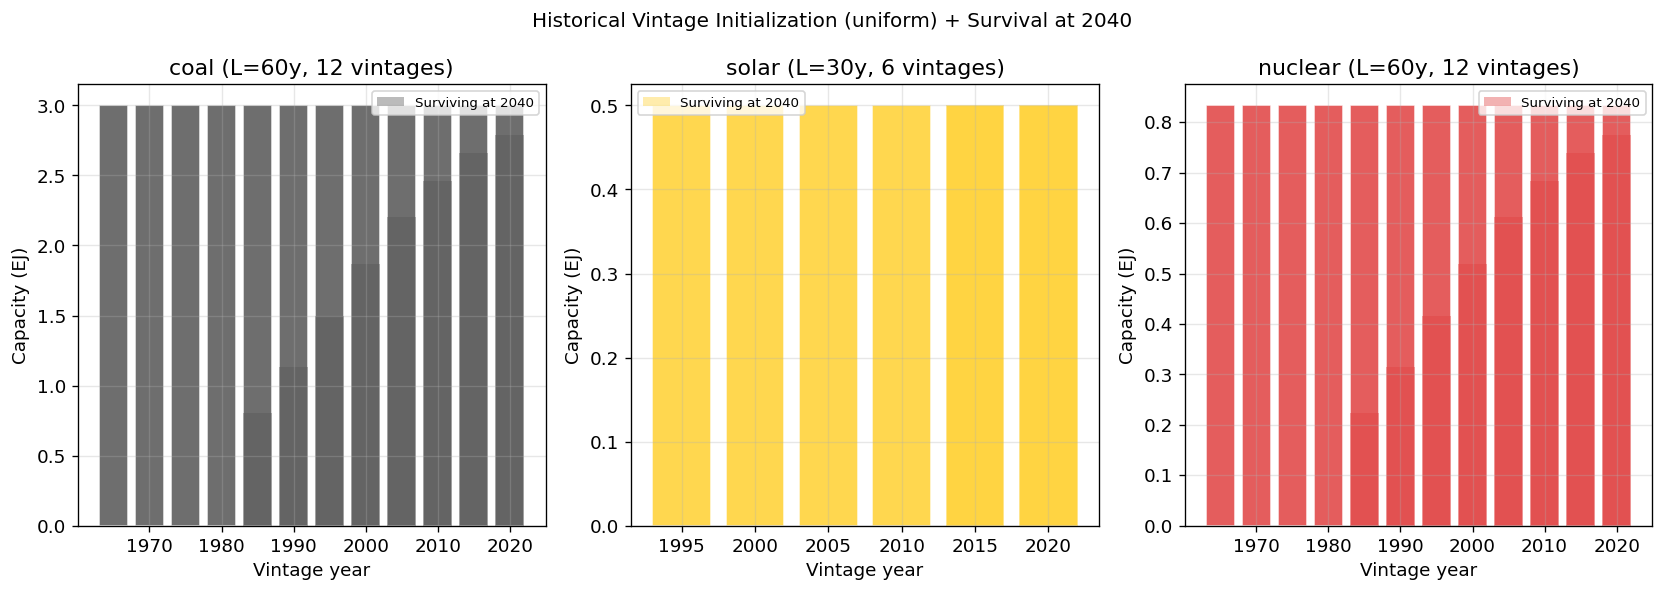

In [13]:
# Visualize initial age distribution for coal, solar, nuclear
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, tech in zip(axes, ['coal', 'solar', 'nuclear']):
    lt = lifetimes[tech]
    n_v = max(1, int(lt // TIMESTEP))
    cap = base_shares[tech_names.index(tech)] * base_total_ej
    per_v = cap / n_v
    oldest = BASE_YEAR - int(lt) + TIMESTEP
    vintages = list(range(oldest, BASE_YEAR + 1, TIMESTEP))
    ages = [BASE_YEAR - v for v in vintages]

    ax.bar(vintages, [per_v]*len(vintages), width=4,
           color=colors.get(tech, '#999'), alpha=0.85, edgecolor='white')

    # Overlay: surviving capacity at 2040
    surv_2040 = [per_v * s_curve_survival(2040 - v, lt,
                 0 if tech in hard_cutoff else lt * 0.75)
                 for v in vintages]
    ax.bar(vintages, surv_2040, width=4, color=colors.get(tech, '#999'),
           alpha=0.4, edgecolor='none', label='Surviving at 2040')

    ax.set_xlabel('Vintage year')
    ax.set_ylabel('Capacity (EJ)')
    ax.set_title(f'{tech} (L={lt}y, {n_v} vintages)')
    ax.legend(fontsize=8)

fig.suptitle('Historical Vintage Initialization (uniform) + Survival at 2040', fontsize=12)
plt.tight_layout()
plt.show()

---
# Part 7: Comparison — Share Blending vs Vintage Bins

## 7.1 Scenario A: Coal Ban at 2035

Compare two approaches when coal is banned (no new investment) starting in 2035:

- **Share blending** ($\tau=40$): Coal share decays exponentially with blend rate $\Delta t / \tau = 0.125$
- **Vintage bins** ($L=60$): Coal capacity decays via S-curve; zero new investment after 2035

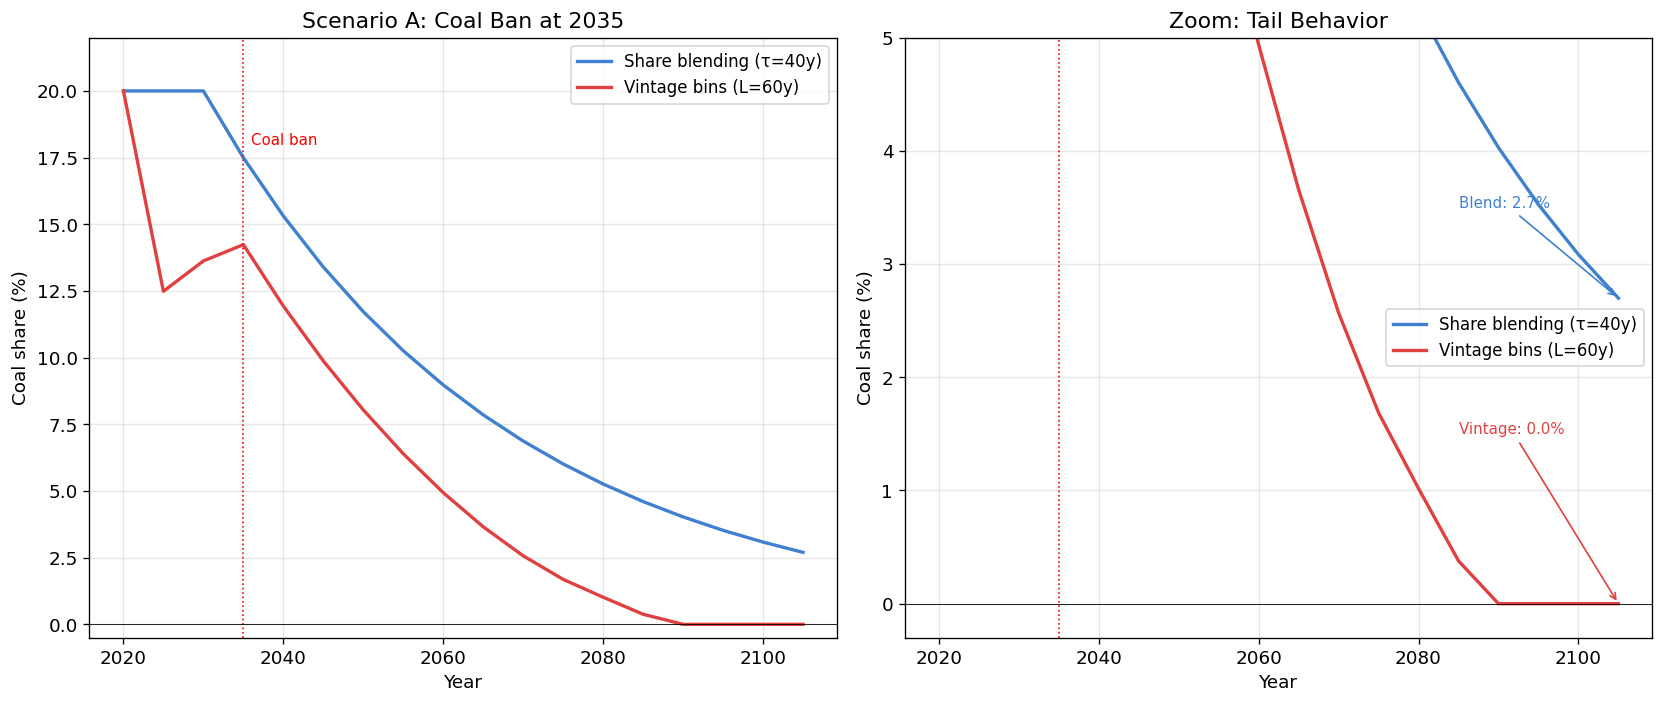


At 2105:
  Share blending: 2.70% coal remaining (asymptotic tail)
  Vintage bins:   0.00% coal remaining

Vintage model reaches 0% when last vintage (2035) reaches age 60: year 2095


In [14]:
# Scenario A: Coal ban at 2035
ban_year = 2035
scenario_years = list(range(2020, 2110, TIMESTEP))

# --- Share blending approach ---
blend_coal = [0.20]  # 20% initial coal share
tau = 40.0
blend_rate = TIMESTEP / tau
for i, yr in enumerate(scenario_years[1:]):
    if yr >= ban_year:
        # Target share = 0 (coal banned)
        new_s = blend_coal[-1] * (1 - blend_rate)
    else:
        new_s = blend_coal[-1]  # no change before ban
    blend_coal.append(max(0, new_s))

# --- Vintage bin approach ---
# Initialize coal capacity at 2020: 20 EJ spread over 12 vintages (60yr / 5yr)
coal_cap = {}
coal_total = 20.0  # 20% of 100 EJ
n_v = 12
per_v = coal_total / n_v
for yr in range(1965, 2021, TIMESTEP):
    coal_cap[yr] = per_v

vintage_coal = [0.20]  # initial share
total_demand = 100.0
for i, yr in enumerate(scenario_years[1:]):
    total_demand *= 1.015 ** TIMESTEP  # 1.5% growth
    # Compute surviving coal capacity
    surv = sum(cap * s_curve_survival(yr - v_yr, 60, 45)
               for v_yr, cap in coal_cap.items())
    # No new coal investment after ban year
    if yr < ban_year:
        # Some new coal investment (20% of gap for simplicity)
        gap = max(0, total_demand * 0.20 - surv)
        if gap > 0:
            coal_cap[yr] = gap * 0.5
    vintage_coal.append(surv / total_demand)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(scenario_years, np.array(blend_coal) * 100,
        label='Share blending (\u03c4=40y)', lw=2, color='#4080D0')
ax.plot(scenario_years, np.array(vintage_coal) * 100,
        label='Vintage bins (L=60y)', lw=2, color='#E04040')
ax.axvline(ban_year, color='red', ls=':', lw=1)
ax.text(ban_year + 1, 18, 'Coal ban', fontsize=9, color='red')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Coal share (%)')
ax.set_title('Scenario A: Coal Ban at 2035')
ax.legend(fontsize=10)
ax.set_ylim(-0.5, 22)

# Zoom on the tail
ax = axes[1]
ax.plot(scenario_years, np.array(blend_coal) * 100,
        label='Share blending (\u03c4=40y)', lw=2, color='#4080D0')
ax.plot(scenario_years, np.array(vintage_coal) * 100,
        label='Vintage bins (L=60y)', lw=2, color='#E04040')
ax.axvline(ban_year, color='red', ls=':', lw=1)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Coal share (%)')
ax.set_title('Zoom: Tail Behavior')
ax.legend(fontsize=10)
ax.set_ylim(-0.3, 5)

# Annotate
last_yr = scenario_years[-1]
axes[1].annotate(f'Blend: {blend_coal[-1]*100:.1f}%',
                 xy=(last_yr, blend_coal[-1]*100),
                 xytext=(last_yr - 20, 3.5),
                 fontsize=9, color='#4080D0',
                 arrowprops=dict(arrowstyle='->', color='#4080D0'))
axes[1].annotate(f'Vintage: {vintage_coal[-1]*100:.1f}%',
                 xy=(last_yr, vintage_coal[-1]*100),
                 xytext=(last_yr - 20, 1.5),
                 fontsize=9, color='#E04040',
                 arrowprops=dict(arrowstyle='->', color='#E04040'))

plt.tight_layout()
plt.show()

print(f'\nAt {last_yr}:')
print(f'  Share blending: {blend_coal[-1]*100:.2f}% coal remaining (asymptotic tail)')
print(f'  Vintage bins:   {vintage_coal[-1]*100:.2f}% coal remaining')
print(f'\nVintage model reaches 0% when last vintage (2035) reaches age 60: year {ban_year + 60}')

## 7.2 Scenario B: Carbon Price $0→$250/tC Ramp (2020–2060)

Compare vintage bins with S-curve only vs S-curve + profit shutdown under a steeper carbon price ramp that crosses the coal breakeven (~$188/tC).

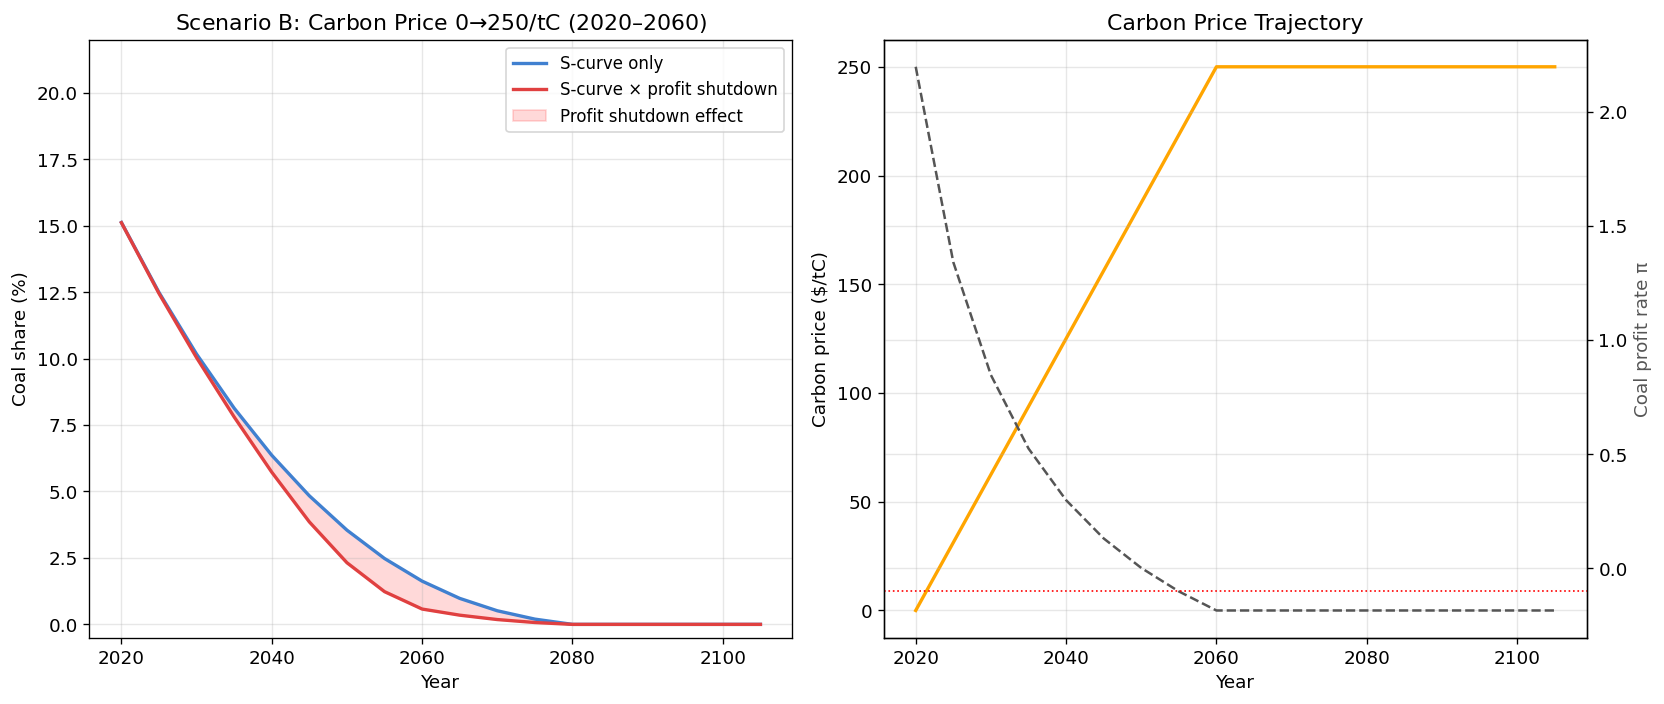

S-curve only: coal < 5% at 2045
S-curve + profit: coal < 5% at 2045


In [15]:
# Scenario B: Carbon price ramp
scenario_years_b = list(range(2020, 2110, TIMESTEP))

# Carbon price: $0 in 2020, ramp to $250/tC by 2060, hold constant
def carbon_price_at(yr):
    if yr <= 2020:
        return 0.0
    elif yr <= 2060:
        return 250.0 * (yr - 2020) / 40.0
    else:
        return 250.0

# Coal parameters for profit rate computation
fuel_p = 2.0       # $/GJ coal
eff = 0.39
om_var = 0.5       # $/GJ output
c_coef = 0.0257    # tC/GJ fuel
p_elec = 18.0      # $/GJ elec price

# --- S-curve only ---
cap_scurve = {}
coal_total_s = 20.0
for yr in range(1965, 2021, TIMESTEP):
    cap_scurve[yr] = coal_total_s / 12

scurve_only_share = []
demand_b = 100.0
for yr in scenario_years_b:
    surv = sum(c * s_curve_survival(yr - v, 60, 45)
               for v, c in cap_scurve.items())
    scurve_only_share.append(surv / demand_b)
    demand_b *= 1.015 ** TIMESTEP

# --- S-curve + profit shutdown ---
cap_profit = {}
for yr in range(1965, 2021, TIMESTEP):
    cap_profit[yr] = coal_total_s / 12

combined_share = []
demand_b = 100.0
for yr in scenario_years_b:
    cp = carbon_price_at(yr)
    var_cost = fuel_p / eff + om_var + cp * c_coef / eff
    pi = (p_elec - var_cost) / abs(var_cost) if var_cost > 0 else 10.0
    p_surv = profit_shutdown(pi)

    surv = sum(c * s_curve_survival(yr - v, 60, 45) * p_surv
               for v, c in cap_profit.items())
    combined_share.append(surv / demand_b)
    demand_b *= 1.015 ** TIMESTEP

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(scenario_years_b, np.array(scurve_only_share) * 100,
        label='S-curve only', lw=2, color='#4080D0')
ax.plot(scenario_years_b, np.array(combined_share) * 100,
        label='S-curve \u00d7 profit shutdown', lw=2, color='#E04040')
ax.fill_between(scenario_years_b,
                np.array(combined_share) * 100,
                np.array(scurve_only_share) * 100,
                alpha=0.15, color='red', label='Profit shutdown effect')
ax.set_xlabel('Year')
ax.set_ylabel('Coal share (%)')
ax.set_title('Scenario B: Carbon Price $0\u2192$250/tC (2020\u20132060)')
ax.legend(fontsize=10)
ax.set_ylim(-0.5, 22)

# Carbon price trajectory
ax = axes[1]
cp_traj = [carbon_price_at(yr) for yr in scenario_years_b]
ax.plot(scenario_years_b, cp_traj, lw=2, color='orange')
ax.set_xlabel('Year')
ax.set_ylabel('Carbon price ($/tC)')
ax.set_title('Carbon Price Trajectory')

# Also show profit rate on secondary axis
ax2 = ax.twinx()
pi_traj = []
for yr in scenario_years_b:
    cp = carbon_price_at(yr)
    vc = fuel_p / eff + om_var + cp * c_coef / eff
    pi_traj.append((p_elec - vc) / abs(vc) if vc > 0 else 10.0)
ax2.plot(scenario_years_b, pi_traj, lw=1.5, ls='--', color='#555555')
ax2.axhline(-0.1, color='red', ls=':', lw=1)
ax2.set_ylabel('Coal profit rate \u03c0', color='#555555')

plt.tight_layout()
plt.show()

# Find when coal share drops below 5%
for shares, label in [(scurve_only_share, 'S-curve only'), (combined_share, 'S-curve + profit')]:
    for i, yr in enumerate(scenario_years_b):
        if shares[i] < 0.05:
            print(f'{label}: coal < 5% at {yr}')
            break

Profit shutdown accelerates coal retirement significantly under a \$250/tC carbon price ramp. The coal breakeven carbon price is ~\$188/tC — once the ramp crosses this threshold around 2050, coal's variable cost exceeds the electricity price, driving the profit rate deeply negative. The profit shutdown survival factor multiplies with the S-curve, compounding the effect and shutting down coal capacity years earlier than physical aging alone.

This is exactly the mechanism that allows Architecture B to model **policy-driven early retirement** without requiring Architecture C's logit sub-nests.

---
# Part 8: B→C Extensibility

## 8.1 Architecture B vs C

| Aspect | Architecture B | Architecture C |
|--------|---------------|----------------|
| **Data structure** | `capacity[tech][vintage] = EJ` | Same |
| **Retirement** | S-curve + profit shutdown | S-curve caps available capacity |
| **Dispatch** | All surviving capacity produces | Logit competition among (tech, vintage) pairs |
| **Cost for old vintages** | Not used in dispatch | Variable cost only (no capital) |
| **Cost for new vintages** | Full LCOE (for logit target shares) | Full LCOE |
| **New investment** | Fills retirement gap | Fills retirement gap + logit over new builds |
| **Profit shutdown** | Explicit $P(\pi)$ function | Implicit — unprofitable vintages lose logit share |

## 8.2 What B Stores That C Reuses

1. **`capacity[tech][vintage] = EJ`** — Identical data structure. C doesn't add new state.

2. **`s_curve_survival()`** — In C, the S-curve caps the **maximum available** capacity of a vintage. Even if the logit wants to dispatch more, physical survival limits output.

3. **Vintage year** — Enables computing variable cost per cohort: `fuel_price / efficiency + O&M_var`. The key difference is that old vintages have **no capital cost** (sunk), making them cheaper to run than new builds.

## 8.3 What C Adds

**Dispatch via logit**: Within each technology family, vintages compete on variable cost. The logit allocates generation share among (tech, vintage) pairs:

- New vintage: full LCOE (capital + fuel + O\&M)
- Old vintage: variable cost only (fuel + O\&M)
- $\Rightarrow$ Old plants are dispatched first (cheaper), up to their S-curve capacity cap

This splits `retire_and_invest()` into two steps:
1. Compute available capacity per vintage via S-curve
2. Logit dispatch over (tech, vintage) pairs, capped by available capacity

The profit shutdown decider becomes **unnecessary** in Architecture C — unprofitable vintages naturally lose dispatch share through the logit. However, the S-curve still applies as a physical capacity constraint.

In [16]:
# Conceptual sketch of Architecture C dispatch
# NOT for production -- illustrates the extension from B

def arch_c_dispatch(
    capacity,        # same as B: dict[str, dict[int, float]]
    tech_names,
    year,
    total_demand_ej,
    lifetimes,
    fuel_prices,     # dict[str, float]
    tech_efficiencies,  # dict[str, float]
    tech_om_var,     # dict[str, float]
    tech_lcoe,       # dict[str, float] full LCOE for new builds
    logit_exp=-4.0,
    half_life_ratio=0.75,
    hard_cutoff_techs=None,
):
    """Architecture C: logit dispatch over (tech, vintage) pairs.

    Old vintages compete on variable cost; new builds on full LCOE.
    S-curve caps available capacity per vintage.
    """
    if hard_cutoff_techs is None:
        hard_cutoff_techs = {'wind', 'solar'}

    # Step 1: Build (tech, vintage) cost and capacity table
    entries = []  # (tech, vintage_year, available_ej, cost_per_gj)
    for tech in tech_names:
        lt = lifetimes[tech]
        hl = 0 if tech in hard_cutoff_techs else lt * half_life_ratio

        for v_yr, cap in capacity.get(tech, {}).items():
            age = year - v_yr
            if tech in hard_cutoff_techs:
                s = hard_cutoff_survival(age, lt)
            else:
                s = s_curve_survival(age, lt, hl)
            avail = cap * s
            if avail < 1e-10:
                continue
            # Variable cost only for old vintages
            fp = fuel_prices.get(tech, 0.0)
            eff = tech_efficiencies.get(tech, 1.0)
            var_cost = fp / eff + tech_om_var.get(tech, 0.0)
            entries.append((tech, v_yr, avail, var_cost))

        # New build option
        entries.append((tech, year, float('inf'), tech_lcoe[tech]))

    # Step 2: Logit over all entries
    costs = np.array([e[3] for e in entries])
    avails = np.array([e[2] for e in entries])
    weights = costs ** logit_exp  # C^beta
    weights = np.where(np.isfinite(weights), weights, 0.0)
    total_w = weights.sum()
    if total_w <= 0:
        return {}  # degenerate
    shares = weights / total_w

    # Step 3: Allocate demand, capped by available capacity
    allocated = np.minimum(shares * total_demand_ej, avails)
    # Redistribute excess...
    # (simplified -- real implementation would iterate)

    result = {}
    for i, (tech, v_yr, avail, cost) in enumerate(entries):
        key = f'{tech}_v{v_yr}' if v_yr != year else f'{tech}_new'
        result[key] = allocated[i]

    return result

print('Architecture C dispatch sketch defined')
print('Key insight: same capacity data structure, different dispatch logic')

Architecture C dispatch sketch defined
Key insight: same capacity data structure, different dispatch logic


---
# Part 9: Parameter Table & Summary

## 9.1 Full Parameter Table

| Tech | Ret. Lifetime | Half-life | Steepness | Profit median | Profit steep. | Hard cutoff only? |
|------|:---:|:---:|:---:|:---:|:---:|:---:|
| coal | 60 | 45 | 0.1 | −0.1 | 6 | No |
| gas_cc | 45 | 34 | 0.1 | −0.1 | 6 | No |
| nuclear | 60 | 45 | 0.1 | −0.1 | 6 | No |
| hydro | 80 | 60 | 0.1 | — | — | No |
| wind | 30 | — | — | — | — | Yes |
| solar | 30 | — | — | — | — | Yes |
| biomass | 60 | 45 | 0.1 | −0.1 | 6 | No |
| oil | 45 | 34 | 0.1 | −0.5 | 6 | No |
| smr | 30 | 23 | 0.1 | −0.1 | 6 | No |
| electrolysis | 25 | — | — | — | — | Yes |

**Notes**:
- Hydro uses S-curve retirement but no profit shutdown (quasi-permanent infrastructure)
- Oil has a more aggressive profit median (−0.5) — oil plants are dispatched only at high margins
- Renewables and electrolysis use hard cutoff — they either work or they don't
- Half-life = retirement lifetime $\times$ 0.75 (GHIM convention)

## 9.2 Summary

**Architecture B** = vintage bins + S-curve retirement + profit shutdown (optional).

- **S-curve survival** $S(a)$: logistic + displacement correction. Plants work at full capacity for decades, then retire in a concentrated window around the half-life. Hard cutoff at retirement lifetime guarantees zero capacity eventually.

- **Profit shutdown** $P(\pi)$: logistic function of profit rate. When carbon pricing makes fossil plants unprofitable, capacity shuts down early. Multiplicative with S-curve.

- **Vintage tracking**: Physical capacity (EJ) per technology per installation period. New investment fills the retirement gap. Old capacity cannot grow.

- **Extensible to C**: Same data structure. Architecture C replaces the dispatch step with logit competition over (tech, vintage) pairs — old vintages compete on variable cost, new builds on full LCOE.

### Implementation Roadmap

1. `ghim/energy/stock.py` — `VintageStock` class (~200 LOC)
2. `ghim/config.py` — `TECH_LIFETIMES`, `SCURVE_*` parameters
3. `ghim/energy/electricity.py` — Replace `apply_stock_turnover()` with `VintageStock.retire_and_invest()`
4. `ghim/energy/hydrogen.py` — Same pattern
5. `ghim/tests/test_stock.py` — Unit tests for S-curve, profit shutdown, retire_and_invest

Demand sectors (`buildings`, `transport`, `industry`) keep using share blending.